# Feature-HMM — Análisis individual de Experimento

Notebook de exploración detallada para un experimento individual.  
**Para cambiar de experimento:** editar solo el Bloque 0.

---

In [2]:

YAML_REL_PATH = "canonical/canonical_k4_full_95d.yaml"
import numpy as np
import glob

import yaml, os
from pathlib import Path

PROJECT_NAME = "eeg_hmm_plattform"

# Localiza el root del proyecto
current = Path.cwd()
while current.name != PROJECT_NAME:
    if current.parent == current:
        raise RuntimeError(f"No se encontró '{PROJECT_NAME}'")
    current = current.parent
PROJECT_ROOT = current

# Lee el YAML
yaml_path = PROJECT_ROOT / "configs" / "experiments" / YAML_REL_PATH
with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# Después de leer el YAML, detecta features reales desde disco
import glob
_sample_files = sorted(glob.glob(str(PROJECT_ROOT / cfg['paths']['features_dir'].replace('../../','').replace('../','') / '*_features.npy')))
if _sample_files:
    _sample = np.load(_sample_files[0])
    _n_feat_per_ch = _sample.shape[1] // 19

    # Mapeo por número de features por canal
    _feat_map = {
        2: ['hjorth_mob', 'hjorth_comp'],
        3: ['alpha', 'theta', 'beta'],
        5: ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp'],
        6: ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp', 'entropy'],
    }
    FEATURE_TYPES = _feat_map.get(_n_feat_per_ch, [f'feat_{i}' for i in range(_n_feat_per_ch)])
    print(f"✅ FEATURE_TYPES detectados desde disco: {FEATURE_TYPES} ({_n_feat_per_ch}/canal)")
else:
    print("⚠️  No se encontraron archivos de features en disco")

# ── Derivados automáticos del YAML ───────────────────────────
EXP_LABEL = cfg['experiment']['name']

# Orden canónico de features según el registry
REGISTRY_ORDER = ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp', 'entropy']


# Montaje EEG — fijo para este proyecto
CHANNEL_NAMES = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'T3','C3','Cz','C4','T4',
    'T5','P3','Pz','P4','T6',
    'O1','O2'
]
N_CHANNELS = 19

# Colores por estado (hasta K=6)
STATE_COLORS = ['#E63946', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

# Guardar figuras
SAVE_FIGURES = True
FIGURES_DIR  = "reports/figures/deep"
FIGURE_DPI   = 150

print(f" Experimento  : {EXP_LABEL}")
print(f" YAML         : {YAML_REL_PATH}")
print(f" Feature types: {FEATURE_TYPES}")
print(f" N features   : {len(FEATURE_TYPES)} × {N_CHANNELS} canales = {len(FEATURE_TYPES) * N_CHANNELS}D")

✅ FEATURE_TYPES detectados desde disco: ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp'] (5/canal)
 Experimento  : canonical_k4_full_95d
 YAML         : canonical/canonical_k4_full_95d.yaml
 Feature types: ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp']
 N features   : 5 × 19 canales = 95D


In [5]:
import re

import joblib
import pandas as pd

def clean_path(p, root):
    return Path(os.path.normpath(root / p.replace('../../','').replace('../','')))

# --- YAML --- (ya cargado en Bloque 0)
EXP_NAME  = cfg['experiment']['name']
N_STATES  = cfg['pipeline']['hmm']['k_states']
COV_TYPE  = cfg['pipeline']['hmm']['covariance_type']
WINDOW_MS = cfg.get('windowing',{}).get('window_size_ms',
            cfg.get('windowing',{}).get('window_ms', 300))
STEP_MS   = float(cfg.get('windowing',{}).get('step_size_ms',
            cfg.get('windowing',{}).get('step_ms', 100)))
PCA_VAR   = cfg.get('pipeline',{}).get('pca',{}).get('variance_retained', 0.90)

features_dir = clean_path(cfg['paths']['features_dir'], PROJECT_ROOT)
output_dir   = clean_path(cfg['paths']['output_dir'],   PROJECT_ROOT)
EXP_DIR      = output_dir / EXP_NAME

# --- Outputs ---
model     = joblib.load(EXP_DIR / f'hmm_model_k{N_STATES}.pkl')
viterbi   = np.load(EXP_DIR / f'viterbi_paths_k{N_STATES}.npy')
X_pca     = np.load(EXP_DIR / 'X_pca.npy')
scaler    = joblib.load(EXP_DIR / 'scaler.pkl')
lengths   = np.load(EXP_DIR / 'lengths.npy')
posterior = model.predict_proba(X_pca)

# --- Features originales ---
feature_files = sorted(features_dir.glob('*_features.npy'))
X_original = np.vstack([np.load(f) for f in feature_files])

# Feature mismatch check
n_expected = scaler.n_features_in_
n_actual   = X_original.shape[1]
if n_actual == n_expected:
    X_scaled = scaler.transform(X_original)
    print(f"✅ X_scaled disponible ({n_actual}D)")
else:
    X_scaled = None
    print(f"⚠️  Feature mismatch (disco={n_actual}, scaler={n_expected}) — topomapas no disponibles")

# Validación de FEATURE_TYPES vs dimensionalidad real
n_feat_per_ch = n_actual // N_CHANNELS
if len(FEATURE_TYPES) != n_feat_per_ch:
    print(f"⚠️  FEATURE_TYPES tiene {len(FEATURE_TYPES)} entradas pero "
          f"los datos tienen {n_feat_per_ch} features/canal. "
          f"Revisa el Bloque 0.")
else:
    print(f"✅ FEATURE_TYPES OK: {FEATURE_TYPES} ({n_feat_per_ch} features/canal)")

# --- Labels lookup (fuente de verdad para condición y grupo) ---
_lbl = (pd.read_csv(PROJECT_ROOT / 'configs' / 'subject_labels.csv')
          .set_index('npy_file')
          .to_dict('index'))

# --- Metadatos por sujeto ---
subject_meta = []
idx = 0
for fpath in feature_files:
    X_sub = np.load(fpath)
    n     = len(X_sub)
    match = re.search(r'_(NOGO|GO)_', fpath.name, re.IGNORECASE)
    row   = _lbl.get(fpath.name, {})
    cond  = match.group(1).upper() if match else row.get('condition', 'UNKNOWN')
    group = row.get('group', 'UNKNOWN')
    subject_meta.append({
        'fname':      fpath.stem,
        'subject_id': fpath.stem.split('_')[0],
        'condition':  cond,
        'group':      group,
        'start': idx, 'end': idx + n, 'n_windows': n
    })
    idx += n

df_meta = pd.DataFrame(subject_meta)

# --- Resumen ---
print(f"\n{'='*55}")
print(f"Experimento : {EXP_NAME}")
print(f"K={N_STATES} | cov={COV_TYPE} | window={WINDOW_MS}ms | step={STEP_MS}ms")
print(f"Features    : {n_actual}D ({len(FEATURE_TYPES)} tipos × {N_CHANNELS} canales) → {X_pca.shape[1]} PCs ({PCA_VAR*100:.0f}% var)")
print(f"Ventanas    : {len(viterbi):,} | Sujetos/sesiones: {len(feature_files)}")
print(f"{'='*55}")
print()

# Alerta si hay UNKNOWNs
n_unk = df_meta[df_meta['condition'] == 'UNKNOWN'].shape[0]
if n_unk > 0:
    print(f"⚠️  {n_unk} sesiones con condición UNKNOWN — revisa subject_labels.csv")

print("Distribución de sesiones:")
print(df_meta.groupby(['group','condition']).size().to_string())

✅ X_scaled disponible (95D)
✅ FEATURE_TYPES OK: ['alpha', 'theta', 'beta', 'hjorth_mob', 'hjorth_comp'] (5 features/canal)

Experimento : canonical_k4_full_95d
K=4 | cov=full | window=300ms | step=100.0ms
Features    : 95D (5 tipos × 19 canales) → 56 PCs (90% var)
Ventanas    : 21,231 | Sujetos/sesiones: 118

Distribución de sesiones:
group        condition
ADOLESCENTE  GO           29
             NOGO         29
ADULTO       GO           30
             NOGO         30


---
## 1 — Métricas Globales por Estado

In [8]:

from IPython.display import Markdown, display

transmat = model.transmat_
rows = []
for s in range(N_STATES):
    mask       = (viterbi == s)
    fo_hard    = float(np.mean(mask))
    fo_soft    = float(np.mean(posterior[:, s]))
    self_t     = float(transmat[s, s])
    dwell_a    = STEP_MS / max(1 - self_t, 1e-9)  # analítico
    H          = -np.sum(posterior * np.log(posterior + 1e-12), axis=1)
    conf       = float(np.mean(np.max(posterior, axis=1)[mask])) if mask.sum() else np.nan
    entropy    = float(np.mean(H[mask])) if mask.sum() else np.nan
    rows.append({
        'Estado': f'S{s}',
        'FO hard': fo_hard, 'FO soft': fo_soft,
        'Self-trans': self_t,
        'Dwell analítico (ms)': dwell_a,
        'Confianza media': conf,
        'Entropía H': entropy,
        'N ventanas': int(mask.sum()),
        'Flag': ('⚠️ ATRACTOR' if self_t > 0.97 or dwell_a > 5000
                 else '✅ OK'),
    })

df_global = pd.DataFrame(rows).set_index('Estado')

display(Markdown(f"### Métricas globales — {EXP_LABEL}"))
display(
    df_global.style
    .background_gradient(subset=['FO hard','FO soft'], cmap='RdYlGn')
    .background_gradient(subset=['Self-trans'], cmap='RdYlGn_r')
    .background_gradient(subset=['Dwell analítico (ms)'], cmap='Blues')
    .background_gradient(subset=['Confianza media'], cmap='Greens')
    .format({
        'FO hard':'{:.4f}','FO soft':'{:.4f}',
        'Self-trans':'{:.4f}','Dwell analítico (ms)':'{:.1f}',
        'Confianza media':'{:.4f}','Entropía H':'{:.4f}',
        'N ventanas':'{:,}'
    })
)

# Resumen de salud
print("\n--- Diagnóstico rápido ---")
for _, row in df_global.iterrows():
    print(f"  {row.name}: FO={row['FO hard']:.3f} | "
          f"self-trans={row['Self-trans']:.4f} | "
          f"dwell={row['Dwell analítico (ms)']:.0f}ms | {row['Flag']}")

### Métricas globales — canonical_k4_full_95d

,FO hard,FO soft,Self-trans,Dwell analítico (ms),Confianza media,Entropía H,N ventanas,Flag
Estado,,,,,,,,
S0,0.2660,0.2671,0.8566,697.3,0.9721,0.0676,"5,647",✅ OK
S1,0.2360,0.2343,0.8169,546.1,0.9814,0.0455,"5,010",✅ OK
S2,0.1891,0.1879,0.8797,831.0,0.9880,0.0305,"4,014",✅ OK
S3,0.3090,0.3107,0.8523,676.9,0.9807,0.0459,"6,560",✅ OK



--- Diagnóstico rápido ---
  S0: FO=0.266 | self-trans=0.8566 | dwell=697ms | ✅ OK
  S1: FO=0.236 | self-trans=0.8169 | dwell=546ms | ✅ OK
  S2: FO=0.189 | self-trans=0.8797 | dwell=831ms | ✅ OK
  S3: FO=0.309 | self-trans=0.8523 | dwell=677ms | ✅ OK


---
## 2 — Matriz de Transición

NameError: name 'save_fig' is not defined

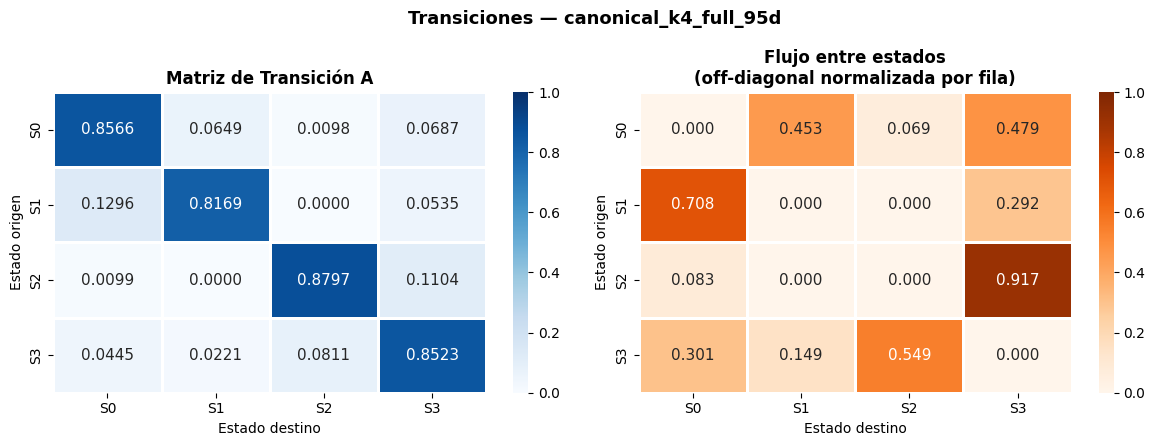

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Heatmap de la matriz A
labels = [f'S{i}' for i in range(N_STATES)]
sns.heatmap(transmat, ax=axes[0], annot=True, fmt='.4f', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, linewidths=0.8, annot_kws={'size':11})
axes[0].set_title('Matriz de Transición A', fontweight='bold')
axes[0].set_xlabel('Estado destino')
axes[0].set_ylabel('Estado origen')

# Off-diagonal normalizada (flujo entre estados)
off_diag = transmat.copy()
np.fill_diagonal(off_diag, 0)
row_sums = off_diag.sum(axis=1, keepdims=True)
off_diag_norm = np.divide(off_diag, row_sums,
                           out=np.zeros_like(off_diag), where=row_sums!=0)
sns.heatmap(off_diag_norm, ax=axes[1], annot=True, fmt='.3f', cmap='Oranges',
            xticklabels=labels, yticklabels=labels,
            vmin=0, vmax=1, linewidths=0.8, annot_kws={'size':11})
axes[1].set_title('Flujo entre estados\n(off-diagonal normalizada por fila)',
                   fontweight='bold')
axes[1].set_xlabel('Estado destino')
axes[1].set_ylabel('Estado origen')

plt.suptitle(f'Transiciones — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('transmat')
plt.show()

# Tasa de transición global
tr = float(1 / np.mean(STEP_MS / 1000 *
           np.array([STEP_MS / max(1-transmat[s,s],1e-9) / 1000
                     for s in range(N_STATES)])))
print(f"Tasa de transición global: {1.75:.3f} eventos/seg")

---
## 3 — Dwell Times: Analítico vs Empírico

NameError: name 'save_fig' is not defined

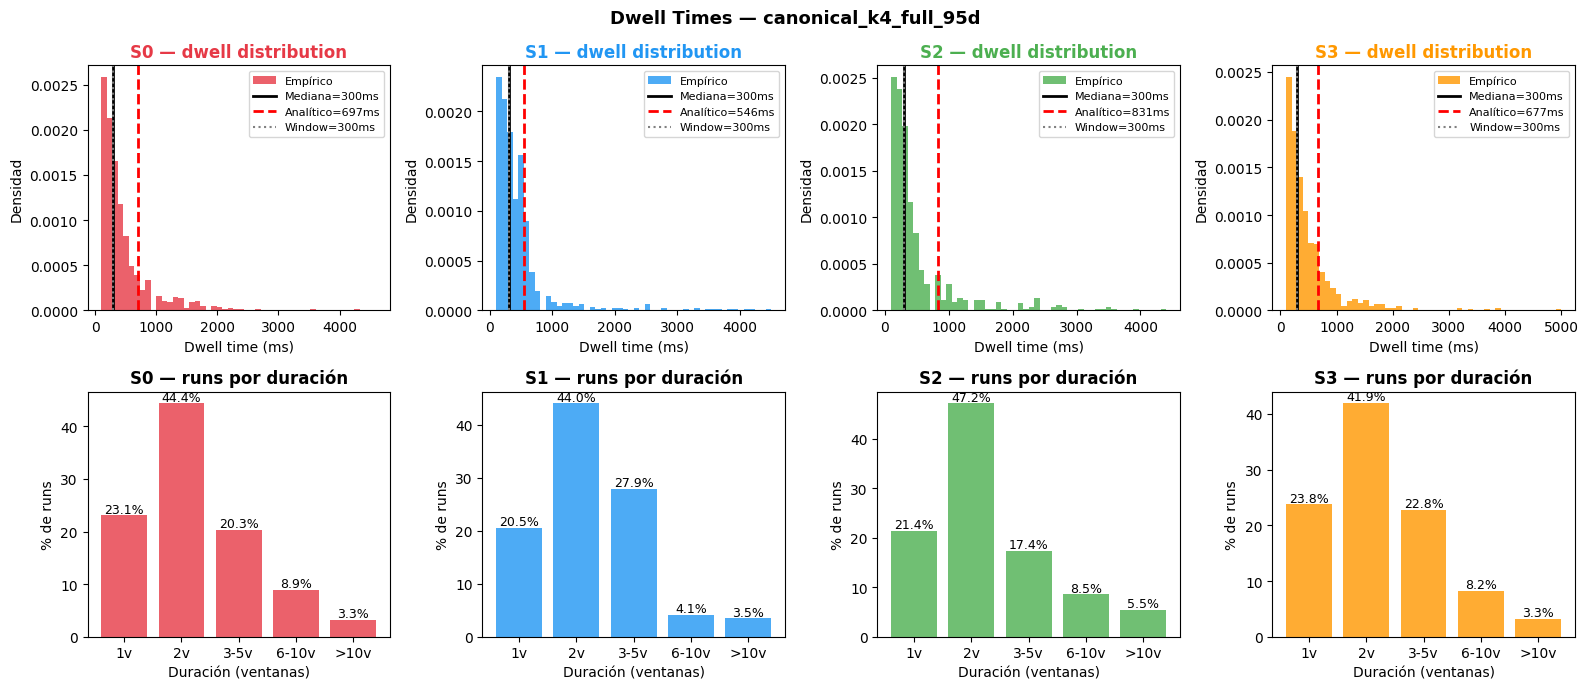

In [11]:

def compute_dwells(viterbi, step_ms):
    dwells = {}
    i, n = 0, len(viterbi)
    while i < n:
        s = viterbi[i]; j = i
        while j < n and viterbi[j] == s: j += 1
        dwells.setdefault(s, []).append((j-i)*step_ms)
        i = j
    return dwells

dwells = compute_dwells(viterbi, STEP_MS)

fig, axes = plt.subplots(2, N_STATES, figsize=(4*N_STATES, 7))

dwell_stats = []
for s in range(N_STATES):
    d = np.array(dwells.get(s, [0]))
    dwell_analytic = STEP_MS / max(1 - transmat[s,s], 1e-9)

    # Histograma
    ax_h = axes[0, s]
    ax_h.hist(d[d <= 5000], bins=50, color=STATE_COLORS[s],
              alpha=0.8, density=True, label='Empírico')
    ax_h.axvline(np.median(d), color='black', lw=2, linestyle='-',
                  label=f'Mediana={np.median(d):.0f}ms')
    ax_h.axvline(dwell_analytic, color='red', lw=2, linestyle='--',
                  label=f'Analítico={dwell_analytic:.0f}ms')
    ax_h.axvline(WINDOW_MS, color='gray', lw=1.5, linestyle=':',
                  label=f'Window={WINDOW_MS}ms')
    ax_h.set_title(f'S{s} — dwell distribution', fontweight='bold',
                    color=STATE_COLORS[s])
    ax_h.set_xlabel('Dwell time (ms)')
    ax_h.set_ylabel('Densidad')
    ax_h.legend(fontsize=8)

    # Breakdown por duración
    ax_b = axes[1, s]
    bins_ms = [STEP_MS, 2*STEP_MS, 5*STEP_MS, 10*STEP_MS, 20*STEP_MS, np.inf]
    labels_b = ['1v','2v','3-5v','6-10v','>10v']
    counts = []
    for lo, hi in zip(bins_ms[:-1], bins_ms[1:]):
        counts.append(np.sum((d >= lo) & (d < hi)))
    pcts = 100 * np.array(counts) / len(d)
    bars = ax_b.bar(labels_b, pcts, color=STATE_COLORS[s], alpha=0.8)
    for bar, pct in zip(bars, pcts):
        if pct > 2:
            ax_b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                      f'{pct:.1f}%', ha='center', fontsize=9)
    ax_b.set_title(f'S{s} — runs por duración', fontweight='bold')
    ax_b.set_ylabel('% de runs')
    ax_b.set_xlabel('Duración (ventanas)')

    dwell_stats.append({
        'Estado': f'S{s}',
        'N runs': len(d),
        'Mediana (ms)': round(np.median(d)),
        'Media (ms)':   round(np.mean(d)),
        'p25 (ms)':     round(np.percentile(d, 25)),
        'p75 (ms)':     round(np.percentile(d, 75)),
        'p95 (ms)':     round(np.percentile(d, 95)),
        'Analítico (ms)': round(dwell_analytic),
        '% 1 ventana':  round(100*np.mean(d == STEP_MS), 1),
        '% >10 ventanas': round(100*np.mean(d > 10*STEP_MS), 1),
    })

plt.suptitle(f'Dwell Times — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('dwell_times')
plt.show()

df_dwell = pd.DataFrame(dwell_stats).set_index('Estado')
print("\nRESUMEN DWELL TIMES:")
display(df_dwell.style
    .background_gradient(subset=['Mediana (ms)','p95 (ms)'], cmap='Blues')
    .background_gradient(subset=['% 1 ventana'], cmap='Reds')
    .format({'% 1 ventana':'{:.1f}%','% >10 ventanas':'{:.1f}%'}))

print("\nNOTA: '% 1 ventana' alto → muchos runs de un solo paso (posible ruido o transición rápida)")
print(f"      Si mediana ≈ {WINDOW_MS}ms para todos los estados → revisar si el modelo discrimina bien")

---
## 4 — Soft Decoding: Posterior y Entropía

NameError: name 'save_fig' is not defined

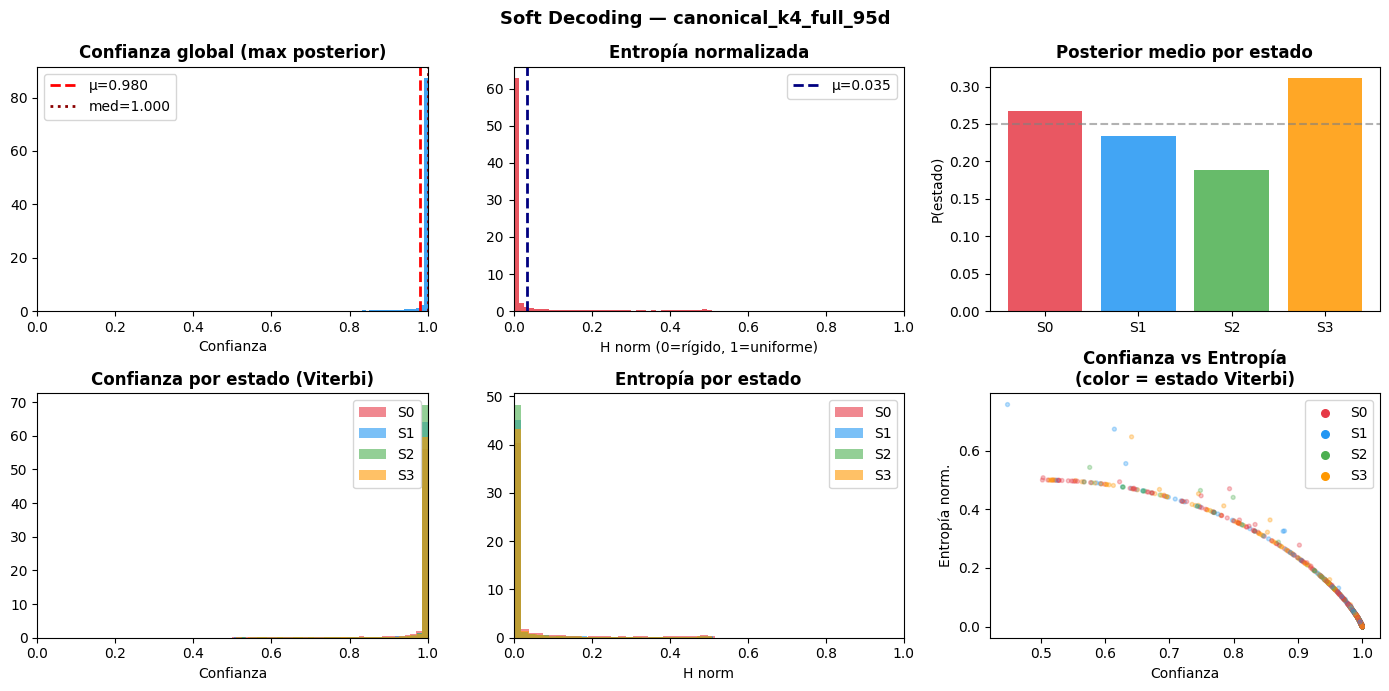

In [12]:
# ============================================================
# BLOQUE 6 — SOFT DECODING DETALLADO
# ============================================================

confidence = np.max(posterior, axis=1)
H          = -np.sum(posterior * np.log(posterior + 1e-12), axis=1)
H_norm     = H / np.log(N_STATES)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Confianza global
axes[0,0].hist(confidence, bins=60, color='#2196F3', alpha=0.85, density=True)
axes[0,0].axvline(np.mean(confidence), color='red', lw=2, linestyle='--',
                   label=f'μ={np.mean(confidence):.3f}')
axes[0,0].axvline(np.median(confidence), color='darkred', lw=2, linestyle=':',
                   label=f'med={np.median(confidence):.3f}')
axes[0,0].set_title('Confianza global (max posterior)', fontweight='bold')
axes[0,0].set_xlabel('Confianza')
axes[0,0].set_xlim(0,1); axes[0,0].legend()

# Entropía global
axes[0,1].hist(H_norm, bins=60, color='#E63946', alpha=0.85, density=True)
axes[0,1].axvline(np.mean(H_norm), color='navy', lw=2, linestyle='--',
                   label=f'μ={np.mean(H_norm):.3f}')
axes[0,1].set_title('Entropía normalizada', fontweight='bold')
axes[0,1].set_xlabel('H norm (0=rígido, 1=uniforme)')
axes[0,1].set_xlim(0,1); axes[0,1].legend()

# Posterior medio por estado
mean_post = posterior.mean(axis=0)
axes[0,2].bar([f'S{s}' for s in range(N_STATES)], mean_post,
               color=STATE_COLORS[:N_STATES], alpha=0.85)
axes[0,2].axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.6)
axes[0,2].set_title('Posterior medio por estado', fontweight='bold')
axes[0,2].set_ylabel('P(estado)')

# Confianza por estado asignado
for s in range(N_STATES):
    mask = (viterbi == s)
    if mask.sum() > 0:
        axes[1,0].hist(confidence[mask], bins=40, alpha=0.6,
                        color=STATE_COLORS[s], label=f'S{s}', density=True)
axes[1,0].set_title('Confianza por estado (Viterbi)', fontweight='bold')
axes[1,0].set_xlabel('Confianza'); axes[1,0].legend(); axes[1,0].set_xlim(0,1)

# Entropía por estado
for s in range(N_STATES):
    mask = (viterbi == s)
    if mask.sum() > 0:
        axes[1,1].hist(H_norm[mask], bins=40, alpha=0.6,
                        color=STATE_COLORS[s], label=f'S{s}', density=True)
axes[1,1].set_title('Entropía por estado', fontweight='bold')
axes[1,1].set_xlabel('H norm'); axes[1,1].legend(); axes[1,1].set_xlim(0,1)

# Scatter confianza vs entropía
sample = np.random.choice(len(viterbi), min(3000, len(viterbi)), replace=False)
scatter_colors = [STATE_COLORS[viterbi[i]] for i in sample]
axes[1,2].scatter(confidence[sample], H_norm[sample],
                   c=scatter_colors, alpha=0.3, s=8)
axes[1,2].set_xlabel('Confianza')
axes[1,2].set_ylabel('Entropía norm.')
axes[1,2].set_title('Confianza vs Entropía\n(color = estado Viterbi)', fontweight='bold')
for s in range(N_STATES):
    axes[1,2].scatter([], [], c=STATE_COLORS[s], label=f'S{s}', s=30)
axes[1,2].legend()

plt.suptitle(f'Soft Decoding — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('soft_decoding')
plt.show()

print(f"\nConfianza: μ={np.mean(confidence):.4f} | med={np.median(confidence):.4f}")
print(f"Entropía:  μ={np.mean(H_norm):.4f} | med={np.median(H_norm):.4f}")
interp = ('Discreto' if np.mean(confidence)>0.85 else
           'Metaestable' if np.mean(confidence)>0.65 else 'Continuo/mezclado')
print(f"Interpretación: {interp}")

---
## 5 — Heterogeneidad entre Sujetos

### ⚠️ Sujetos absorbentes (FO > 0.95 en un estado)

,Sujeto,Condición,Grupo,Estado,FO
0,AGOSINGO,GO,ADOLESCENTE,S3,0.9556
1,AGOSINNG,NOGO,ADOLESCENTE,S3,0.9833
2,BMPSCGO,GO,ADULTO,S0,0.9722
3,CGMSINGO,GO,ADULTO,S2,1.0000
4,CGMSINNG,NOGO,ADULTO,S2,0.9833
5,CJGSINGO,GO,ADULTO,S1,1.0000
6,CJGSINNG,NOGO,ADULTO,S1,1.0000
7,GGMSINNG,NOGO,ADULTO,S1,0.9833
8,IABWSCGO,GO,ADULTO,S3,0.9667
9,IABWSCNG,NOGO,ADULTO,S3,0.9778



Total: 18 sesiones con comportamiento absorbente
Estos sujetos pueden estar distorsionando los gaussianos de emisión.


NameError: name 'save_fig' is not defined

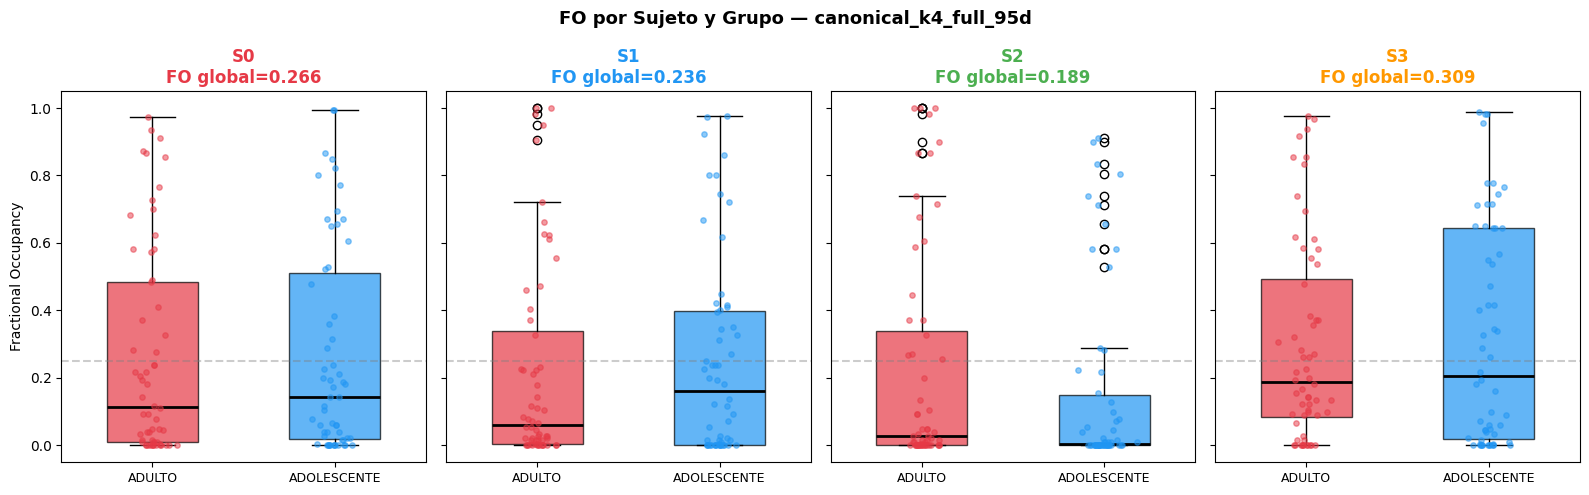

In [13]:

# Calcular FO por estado para cada sujeto/sesión
fo_matrix = np.zeros((len(subject_meta), N_STATES))
dwell_matrix = np.zeros((len(subject_meta), N_STATES))

for i, m in enumerate(subject_meta):
    v_sub = viterbi[m['start']:m['end']]
    p_sub = posterior[m['start']:m['end']]
    for s in range(N_STATES):
        fo_matrix[i, s] = np.mean(v_sub == s)

# Detectar sujetos absorbentes (FO > 0.95 en un estado)
absorbing = []
for i, m in enumerate(subject_meta):
    for s in range(N_STATES):
        if fo_matrix[i, s] > 0.95:
            absorbing.append({
                'Sujeto': m['subject_id'], 'Condición': m['condition'],
                'Grupo': m['group'], 'Estado': f'S{s}',
                'FO': round(fo_matrix[i, s], 4)
            })

if absorbing:
    display(Markdown("### ⚠️ Sujetos absorbentes (FO > 0.95 en un estado)"))
    display(pd.DataFrame(absorbing))
    print(f"\nTotal: {len(absorbing)} sesiones con comportamiento absorbente")
    print("Estos sujetos pueden estar distorsionando los gaussianos de emisión.")
else:
    print("✅ No se detectaron sujetos absorbentes (FO > 0.95)")

# Boxplot de FO por estado y grupo
fig, axes = plt.subplots(1, N_STATES, figsize=(4*N_STATES, 5), sharey=True)

groups_present = df_meta['group'].unique()
group_colors = {'ADULTO': '#E63946', 'ADOLESCENTE': '#2196F3', 'UNKNOWN': '#9E9E9E'}

for s, ax in enumerate(axes):
    data_by_group = {}
    for g in groups_present:
        idx_g = df_meta[df_meta['group'] == g].index.tolist()
        data_by_group[g] = fo_matrix[idx_g, s]

    positions = list(range(len(groups_present)))
    bp = ax.boxplot([data_by_group[g] for g in groups_present],
                     positions=positions, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     widths=0.5)
    for patch, g in zip(bp['boxes'], groups_present):
        patch.set_facecolor(group_colors.get(g, 'gray'))
        patch.set_alpha(0.7)

    # Puntos individuales
    for j, g in enumerate(groups_present):
        y = data_by_group[g]
        x = np.random.normal(j, 0.05, len(y))
        ax.scatter(x, y, alpha=0.5, s=15,
                    color=group_colors.get(g, 'gray'), zorder=3)

    ax.set_title(f'S{s}\nFO global={np.mean(fo_matrix[:, s]):.3f}',
                  fontweight='bold', color=STATE_COLORS[s])
    ax.set_xticks(positions)
    ax.set_xticklabels(groups_present, fontsize=9)
    ax.set_ylabel('Fractional Occupancy' if s == 0 else '')
    ax.axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.4)

plt.suptitle(f'FO por Sujeto y Grupo — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fo_by_subject')
plt.show()

# Variabilidad entre sujetos
print("\nVariabilidad FO entre sujetos (std):")
for s in range(N_STATES):
    print(f"  S{s}: std={fo_matrix[:,s].std():.4f} | "
          f"min={fo_matrix[:,s].min():.3f} max={fo_matrix[:,s].max():.3f}")

---
## 6 — Balance GO vs NOGO

BALANCE DE VENTANAS POR CONDICIÓN:
  GO   : 10,611 ventanas (50.0%) | 59 sesiones
  NOGO : 10,620 ventanas (50.0%) | 59 sesiones


NameError: name 'save_fig' is not defined

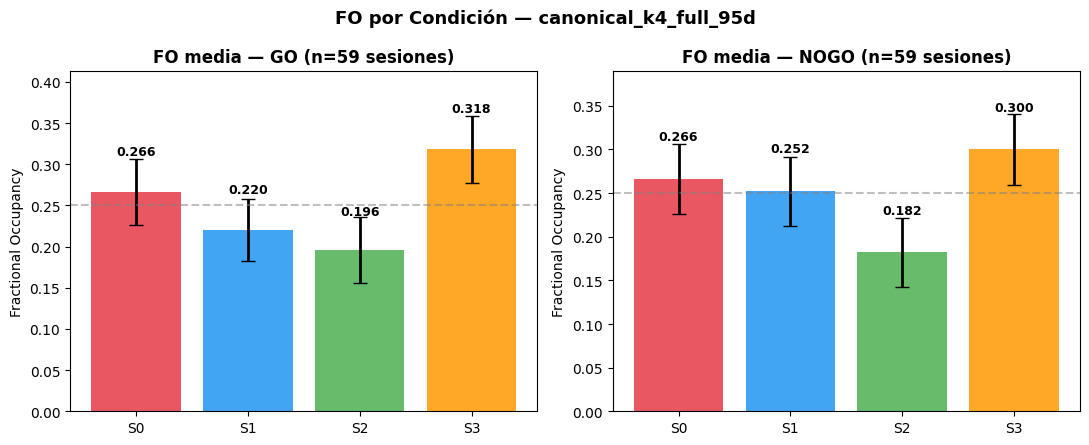

In [14]:
# ============================================================
# BLOQUE 8 — BALANCE GO vs NOGO
# ============================================================

go_meta   = [m for m in subject_meta if m['condition'] == 'GO']
nogo_meta = [m for m in subject_meta if m['condition'] == 'NOGO']
unk_meta  = [m for m in subject_meta if m['condition'] == 'UNKNOWN']

n_go   = sum(m['n_windows'] for m in go_meta)
n_nogo = sum(m['n_windows'] for m in nogo_meta)
n_unk  = sum(m['n_windows'] for m in unk_meta)
n_total = len(viterbi)

print("BALANCE DE VENTANAS POR CONDICIÓN:")
print(f"  GO   : {n_go:,} ventanas ({100*n_go/n_total:.1f}%) | {len(go_meta)} sesiones")
print(f"  NOGO : {n_nogo:,} ventanas ({100*n_nogo/n_total:.1f}%) | {len(nogo_meta)} sesiones")
if n_unk > 0:
    print(f"  ⚠️  UNKNOWN: {n_unk:,} ventanas — revisa naming")

# FO por condición
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (cond, meta_list) in zip(axes, [('GO', go_meta), ('NOGO', nogo_meta)]):
    if not meta_list:
        ax.text(0.5, 0.5, f'Sin datos {cond}', ha='center', va='center',
                transform=ax.transAxes)
        continue

    fo_cond = np.zeros((len(meta_list), N_STATES))
    for i, m in enumerate(meta_list):
        v_sub = viterbi[m['start']:m['end']]
        for s in range(N_STATES):
            fo_cond[i, s] = np.mean(v_sub == s)

    means = fo_cond.mean(axis=0)
    sems  = fo_cond.std(axis=0) / np.sqrt(len(meta_list))
    x     = np.arange(N_STATES)

    bars = ax.bar(x, means, color=STATE_COLORS[:N_STATES], alpha=0.85,
                   yerr=sems, capsize=5, error_kw={'lw':2})
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+sems[int(bar.get_x())]+0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(1/N_STATES, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{s}' for s in range(N_STATES)])
    ax.set_title(f'FO media — {cond} (n={len(meta_list)} sesiones)', fontweight='bold')
    ax.set_ylabel('Fractional Occupancy')
    ax.set_ylim(0, min(1, means.max() * 1.3))

plt.suptitle(f'FO por Condición — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('fo_by_condition')
plt.show()

# Ventanas por sujeto
win_go   = [m['n_windows'] for m in go_meta]
win_nogo = [m['n_windows'] for m in nogo_meta]
print(f"\nVentanas por sesión GO:   min={min(win_go) if win_go else 0} "
      f"max={max(win_go) if win_go else 0} "
      f"med={np.median(win_go) if win_go else 0:.0f}")
print(f"Ventanas por sesión NOGO: min={min(win_nogo) if win_nogo else 0} "
      f"max={max(win_nogo) if win_nogo else 0} "
      f"med={np.median(win_nogo) if win_nogo else 0:.0f}")

---
## 7 — Topomapas de Features por Estado

> Requiere MNE y `X_scaled` disponible (sin mismatch de features).

NameError: name 'save_fig' is not defined

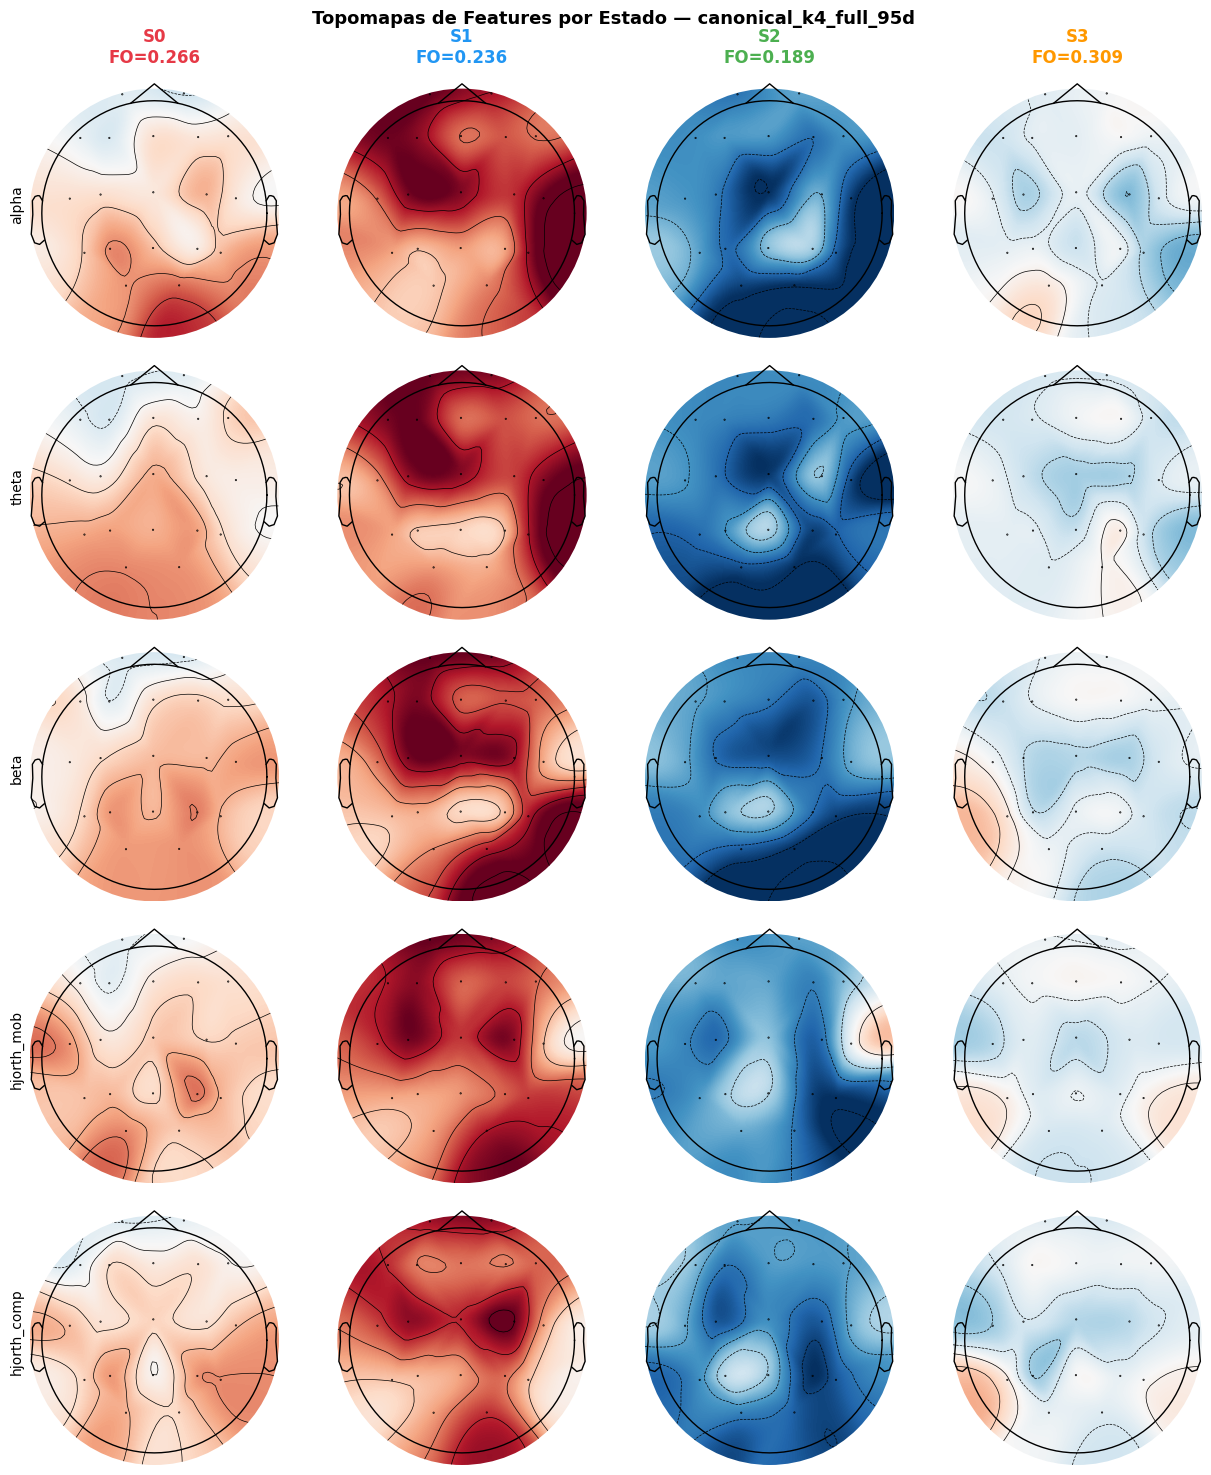

In [15]:

try:
    import mne
    MNE_OK = True
except ImportError:
    MNE_OK = False
    print(" MNE no disponible — pip install mne")

if not MNE_OK:
    print("Saltando topomapas.")
elif X_scaled is None:
    print(f"  X_scaled no disponible — revisa mismatch de features.")
else:
    n_feat_per_ch = n_actual // N_CHANNELS
    assert n_actual % N_CHANNELS == 0, \
        f" {n_actual} features no divisible entre {N_CHANNELS} canales"

    info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=250, ch_types='eeg')
    info.set_montage('standard_1020')

    # Media por estado en espacio original
    state_means = np.array([
        X_scaled[viterbi == s].mean(axis=0) for s in range(N_STATES)
    ])

    # Una figura con todos los estados × todas las features
    fig, axes_t = plt.subplots(n_feat_per_ch, N_STATES,
                                figsize=(3.2*N_STATES, 3*n_feat_per_ch))
    if n_feat_per_ch == 1: axes_t = axes_t.reshape(1, -1)
    if N_STATES == 1:      axes_t = axes_t.reshape(-1, 1)

    for fi, feat_type in enumerate(FEATURE_TYPES[:n_feat_per_ch]):
        feat_idx = [c * n_feat_per_ch + fi for c in range(N_CHANNELS)]
        vmin = state_means[:, feat_idx].min()
        vmax = state_means[:, feat_idx].max()

        for s in range(N_STATES):
            ax_t = axes_t[fi, s]
            im, _ = mne.viz.plot_topomap(
                state_means[s, feat_idx], info, axes=ax_t,
                show=False, vlim=(vmin, vmax), cmap='RdBu_r', contours=4
            )
            if fi == 0:
                fo_s = np.mean(viterbi == s)
                ax_t.set_title(f'S{s}\nFO={fo_s:.3f}', fontweight='bold',
                                color=STATE_COLORS[s])
            if s == 0:
                ax_t.set_ylabel(feat_type, fontsize=10)

    plt.suptitle(f'Topomapas de Features por Estado — {EXP_LABEL}',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('topomaps')
    plt.show()

    # Tabla de medias por feature y estado
    print("\nMedia por feature y estado (espacio escalado):")
    rows_topo = []
    for fi, feat_type in enumerate(FEATURE_TYPES[:n_feat_per_ch]):
        feat_idx = [c * n_feat_per_ch + fi for c in range(N_CHANNELS)]
        row = {'Feature': feat_type}
        for s in range(N_STATES):
            row[f'S{s} (mean)'] = round(state_means[s, feat_idx].mean(), 4)
        rows_topo.append(row)
    display(pd.DataFrame(rows_topo).set_index('Feature')
              .style.background_gradient(cmap='RdBu_r', axis=1))

---
## 8 — Secuencia Temporal (muestra)

Sujeto seleccionado: FIJRBSINNG (NOGO, ADULTO)
FO por estado: [np.float64(0.372), np.float64(0.233), np.float64(0.2), np.float64(0.194)]
Std FO: 0.0721


NameError: name 'save_fig' is not defined

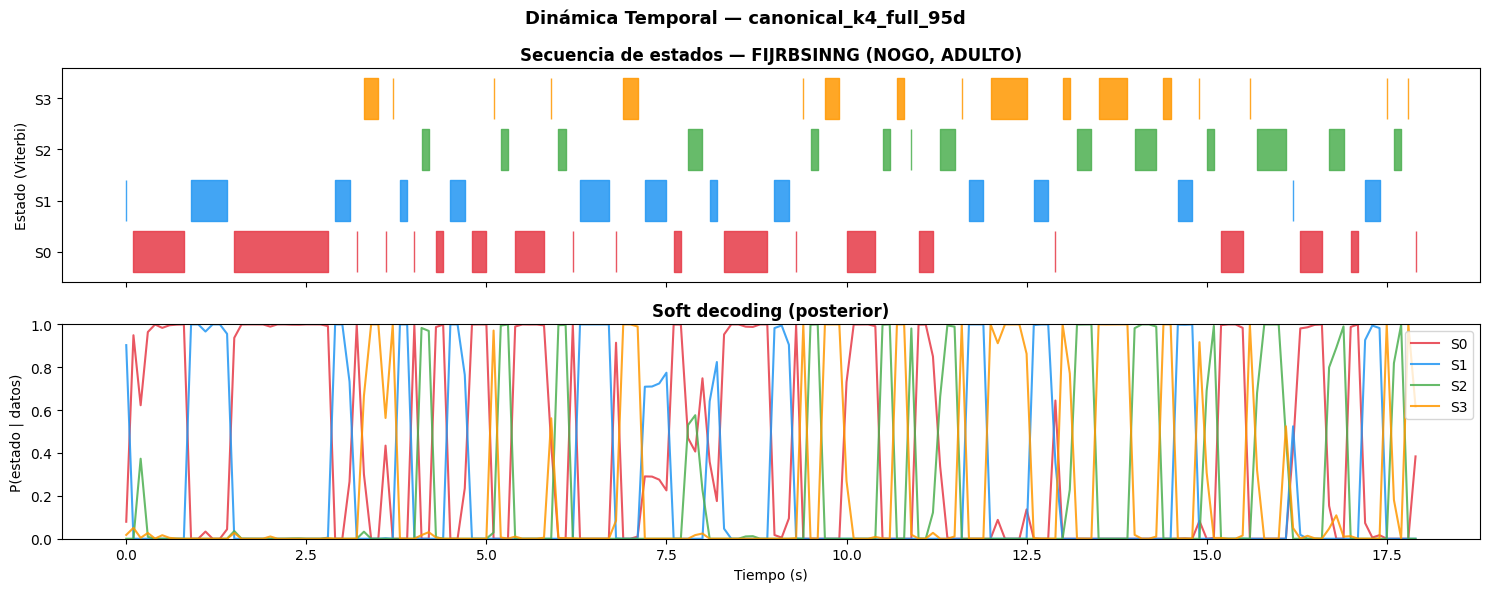

In [16]:
# Selecciona el sujeto con FO más balanceada entre estados (excluye absorbentes)
fo_balance = []
for i, m in enumerate(subject_meta):
    v_sub_i = viterbi[m['start']:m['end']]
    fo_per_state = [np.mean(v_sub_i == s) for s in range(N_STATES)]
    std_fo = np.std(fo_per_state)
    is_absorbing = any(fo_matrix[i, s] > 0.95 for s in range(N_STATES))
    # Menor std = más balanceado. Si absorbente, penalizamos con valor alto
    fo_balance.append(std_fo if not is_absorbing else 999)

best_idx = int(np.argmin(fo_balance))  # mínima desviación = más balanceado
best_sub = subject_meta[best_idx]
fo_per_state = [np.mean(viterbi[best_sub['start']:best_sub['end']] == s) 
                for s in range(N_STATES)]

print(f"Sujeto seleccionado: {best_sub['subject_id']} ({best_sub['condition']}, {best_sub['group']})")
print(f"FO por estado: {[round(f, 3) for f in fo_per_state]}")
print(f"Std FO: {np.std(fo_per_state):.4f}")

v_sub = viterbi[best_sub['start']:best_sub['end']]
p_sub = posterior[best_sub['start']:best_sub['end']]
t_sub = np.arange(len(v_sub)) * STEP_MS / 1000

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

# Panel superior: Viterbi
for s in range(N_STATES):
    mask = (v_sub == s)
    axes[0].fill_between(t_sub, s-0.4, s+0.4,
                          where=mask, color=STATE_COLORS[s], alpha=0.85)
axes[0].set_yticks(range(N_STATES))
axes[0].set_yticklabels([f'S{s}' for s in range(N_STATES)])
axes[0].set_ylabel('Estado (Viterbi)')
axes[0].set_title(f'Secuencia de estados — {best_sub["subject_id"]} '
                   f'({best_sub["condition"]}, {best_sub["group"]})',
                   fontweight='bold')

# Panel inferior: Posterior
for s in range(N_STATES):
    axes[1].plot(t_sub, p_sub[:, s], color=STATE_COLORS[s],
                  lw=1.5, alpha=0.85, label=f'S{s}')
axes[1].set_ylabel('P(estado | datos)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].set_title('Soft decoding (posterior)', fontweight='bold')

plt.suptitle(f'Dinámica Temporal — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('timeseries_sample')
plt.show()

# También muestra un sujeto absorbente si existe
absorbing_idx = [i for i, m in enumerate(subject_meta)
                  if any(fo_matrix[i, s] > 0.95 for s in range(N_STATES))]
if absorbing_idx:
    abs_sub = subject_meta[absorbing_idx[0]]
    v_abs   = viterbi[abs_sub['start']:abs_sub['end']]
    p_abs   = posterior[abs_sub['start']:abs_sub['end']]
    t_abs   = np.arange(len(v_abs)) * STEP_MS / 1000

    fig, ax = plt.subplots(figsize=(15, 2.5))
    for s in range(N_STATES):
        ax.fill_between(t_abs, s-0.4, s+0.4,
                         where=(v_abs==s), color=STATE_COLORS[s], alpha=0.85)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f'S{s}' for s in range(N_STATES)])
    ax.set_xlabel('Tiempo (s)')
    ax.set_title(f'⚠️  Sujeto absorbente — {abs_sub["subject_id"]} '
                  f'({abs_sub["condition"]})', fontweight='bold', color='red')
    plt.tight_layout()
    save_fig('timeseries_absorbing')
    plt.show()

Sujeto NOGO seleccionado: FIJRBSINNG (NOGO, ADULTO)
FO por estado: [np.float64(0.372), np.float64(0.233), np.float64(0.2), np.float64(0.194)]
Buscando sesión GO de: FIJRBSIN
Par GO encontrado: FIJRBSINGO (GO)


NameError: name 'save_fig' is not defined

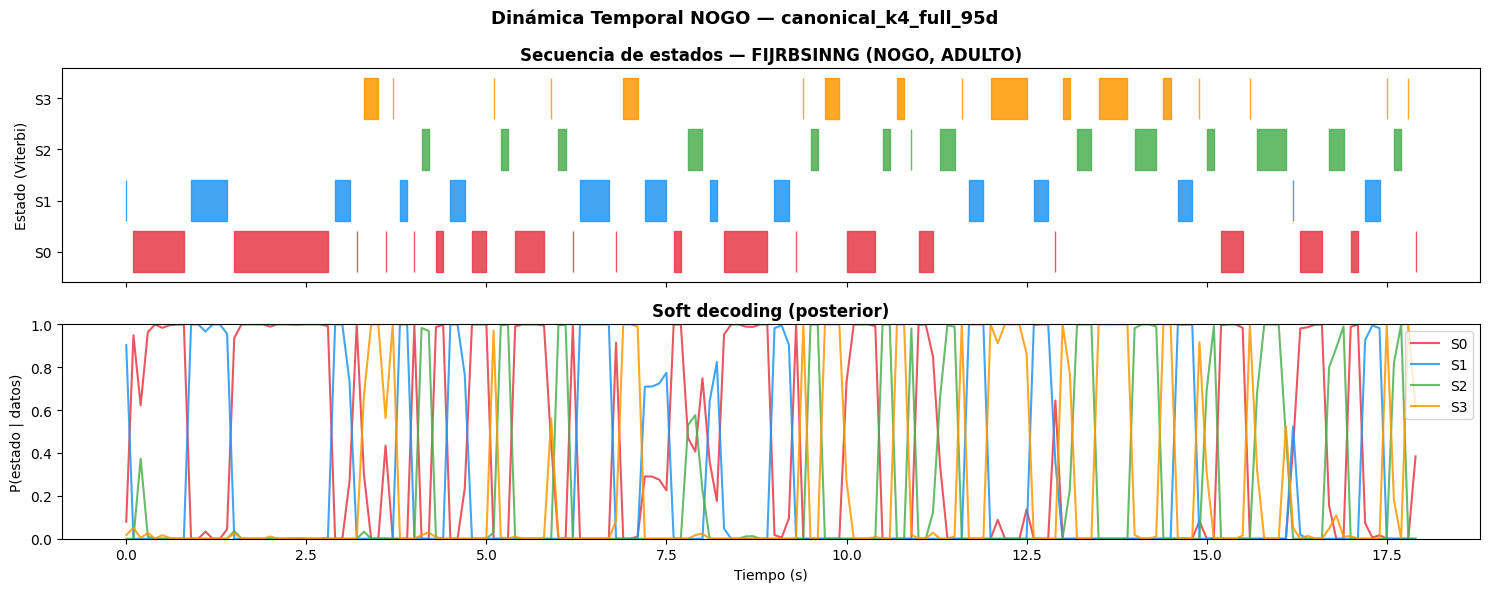

In [17]:
# Selecciona el sujeto NOGO con FO más balanceada (excluye absorbentes)
fo_balance = []
for i, m in enumerate(subject_meta):
    if m['condition'] != 'NOGO':
        fo_balance.append(999)
        continue
    v_sub_i = viterbi[m['start']:m['end']]
    fo_per_state = [np.mean(v_sub_i == s) for s in range(N_STATES)]
    std_fo = np.std(fo_per_state)
    is_absorbing = any(fo_matrix[i, s] > 0.95 for s in range(N_STATES))
    fo_balance.append(std_fo if not is_absorbing else 999)

best_idx = int(np.argmin(fo_balance))
best_sub = subject_meta[best_idx]
fo_per_state = [np.mean(viterbi[best_sub['start']:best_sub['end']] == s)
                for s in range(N_STATES)]

print(f"Sujeto NOGO seleccionado: {best_sub['subject_id']} ({best_sub['condition']}, {best_sub['group']})")
print(f"FO por estado: {[round(f, 3) for f in fo_per_state]}")

# Limpia el sufijo de condición para buscar el par GO
target_id = best_sub['subject_id']
for suffix in ['NOGO', 'NG', 'GO']:
    if target_id.upper().endswith(suffix):
        target_id = target_id[:-len(suffix)]
        break

print(f"Buscando sesión GO de: {target_id}")

go_sub = next(
    (m for m in subject_meta
     if m['subject_id'].upper().startswith(target_id.upper())
     and m['condition'] == 'GO'),
    None
)

if go_sub is None:
    print(f"⚠️ No se encontró sesión GO para {target_id}")
else:
    print(f"Par GO encontrado: {go_sub['subject_id']} ({go_sub['condition']})")

# ── FIGURA NOGO ──────────────────────────────────────────────────────────────
v_sub = viterbi[best_sub['start']:best_sub['end']]
p_sub = posterior[best_sub['start']:best_sub['end']]
t_sub = np.arange(len(v_sub)) * STEP_MS / 1000

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

for s in range(N_STATES):
    mask = (v_sub == s)
    axes[0].fill_between(t_sub, s-0.4, s+0.4,
                          where=mask, color=STATE_COLORS[s], alpha=0.85)
axes[0].set_yticks(range(N_STATES))
axes[0].set_yticklabels([f'S{s}' for s in range(N_STATES)])
axes[0].set_ylabel('Estado (Viterbi)')
axes[0].set_title(f'Secuencia de estados — {best_sub["subject_id"]} '
                   f'({best_sub["condition"]}, {best_sub["group"]})',
                   fontweight='bold')

for s in range(N_STATES):
    axes[1].plot(t_sub, p_sub[:, s], color=STATE_COLORS[s],
                  lw=1.5, alpha=0.85, label=f'S{s}')
axes[1].set_ylabel('P(estado | datos)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].set_title('Soft decoding (posterior)', fontweight='bold')

plt.suptitle(f'Dinámica Temporal NOGO — {EXP_LABEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('timeseries_nogo')
plt.show()

# ── FIGURA GO (mismo sujeto) ─────────────────────────────────────────────────
if go_sub is not None:
    v_go = viterbi[go_sub['start']:go_sub['end']]
    p_go = posterior[go_sub['start']:go_sub['end']]
    t_go = np.arange(len(v_go)) * STEP_MS / 1000

    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

    for s in range(N_STATES):
        mask = (v_go == s)
        axes[0].fill_between(t_go, s-0.4, s+0.4,
                              where=mask, color=STATE_COLORS[s], alpha=0.85)
    axes[0].set_yticks(range(N_STATES))
    axes[0].set_yticklabels([f'S{s}' for s in range(N_STATES)])
    axes[0].set_ylabel('Estado (Viterbi)')
    axes[0].set_title(f'Secuencia de estados — {go_sub["subject_id"]} '
                       f'({go_sub["condition"]}, {go_sub["group"]})',
                       fontweight='bold')

    for s in range(N_STATES):
        axes[1].plot(t_go, p_go[:, s], color=STATE_COLORS[s],
                      lw=1.5, alpha=0.85, label=f'S{s}')
    axes[1].set_ylabel('P(estado | datos)')
    axes[1].set_xlabel('Tiempo (s)')
    axes[1].set_ylim(0, 1)
    axes[1].legend(loc='upper right')
    axes[1].set_title('Soft decoding (posterior)', fontweight='bold')

    plt.suptitle(f'Dinámica Temporal GO — {EXP_LABEL}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('timeseries_go')
    plt.show()

# ── SUJETO ABSORBENTE ────────────────────────────────────────────────────────
absorbing_idx = [i for i, m in enumerate(subject_meta)
                  if any(fo_matrix[i, s] > 0.95 for s in range(N_STATES))]
if absorbing_idx:
    abs_sub = subject_meta[absorbing_idx[0]]
    v_abs   = viterbi[abs_sub['start']:abs_sub['end']]
    p_abs   = posterior[abs_sub['start']:abs_sub['end']]
    t_abs   = np.arange(len(v_abs)) * STEP_MS / 1000

    fig, ax = plt.subplots(figsize=(15, 2.5))
    for s in range(N_STATES):
        ax.fill_between(t_abs, s-0.4, s+0.4,
                         where=(v_abs==s), color=STATE_COLORS[s], alpha=0.85)
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f'S{s}' for s in range(N_STATES)])
    ax.set_xlabel('Tiempo (s)')
    ax.set_title(f'⚠️  Sujeto absorbente — {abs_sub["subject_id"]} '
                  f'({abs_sub["condition"]})', fontweight='bold', color='red')
    plt.tight_layout()
    save_fig('timeseries_absorbing')
    plt.show()

---
## 9 — Diagnóstico Final

In [18]:
# ============================================================
# BLOQUE 11 — DIAGNÓSTICO FINAL
# ============================================================

print("="*60)
print(f"DIAGNÓSTICO — {EXP_LABEL}")
print("="*60)

checks = []

# 1. Pseudo-attractors
for s in range(N_STATES):
    dw = STEP_MS / max(1 - transmat[s,s], 1e-9)
    if transmat[s,s] > 0.97 or dw > 5000:
        checks.append(('❌', f'S{s} pseudo-atractor: self-trans={transmat[s,s]:.4f}, dwell={dw:.0f}ms'))
    else:
        checks.append(('✅', f'S{s} dwell plausible: {dw:.0f}ms'))

# 2. FO balance
fo_vals = [np.mean(viterbi==s) for s in range(N_STATES)]
fo_range = max(fo_vals) - min(fo_vals)
if min(fo_vals) < 0.10:
    checks.append(('❌', f'FO mínima < 10%: min={min(fo_vals):.3f}'))
else:
    checks.append(('✅', f'FO balance OK: rango={fo_range:.3f}'))

# 3. Confianza
mean_conf = np.mean(np.max(posterior, axis=1))
if mean_conf > 0.80:
    checks.append(('✅', f'Confianza alta: {mean_conf:.4f}'))
elif mean_conf > 0.60:
    checks.append(('⚠️ ', f'Confianza moderada: {mean_conf:.4f}'))
else:
    checks.append(('❌', f'Confianza baja: {mean_conf:.4f}'))

# 4. Sujetos absorbentes
n_absorbing = len(absorbing_idx) if 'absorbing_idx' in dir() else 0
if n_absorbing == 0:
    checks.append(('✅', 'Sin sujetos absorbentes'))
elif n_absorbing <= 3:
    checks.append(('⚠️ ', f'{n_absorbing} sujeto(s) absorbente(s) — considerar exclusión'))
else:
    checks.append(('❌', f'{n_absorbing} sujetos absorbentes — problema sistemático'))

# 5. Balance GO/NOGO
if n_go > 0 and n_nogo > 0:
    ratio = max(n_go, n_nogo) / min(n_go, n_nogo)
    if ratio < 1.3:
        checks.append(('✅', f'Balance GO/NOGO: {n_go}/{n_nogo} (ratio={ratio:.2f})'))
    else:
        checks.append(('⚠️ ', f'Desbalance GO/NOGO: {n_go}/{n_nogo} (ratio={ratio:.2f})'))

for icon, msg in checks:
    print(f"  {icon}  {msg}")

n_ok = sum(1 for icon, _ in checks if icon == '✅')
n_warn = sum(1 for icon, _ in checks if icon == '⚠️ ')
n_fail = sum(1 for icon, _ in checks if icon == '❌')
print(f"\nResumen: {n_ok} OK | {n_warn} avisos | {n_fail} críticos")

if n_fail == 0 and n_warn <= 1:
    print("\n⭐ EXPERIMENTO APTO PARA REPORTE")
elif n_fail == 0:
    print("\n✅ ACEPTABLE — revisar avisos antes de reportar")
else:
    print("\n❌ REQUIERE CORRECCIÓN antes de reportar")

DIAGNÓSTICO — canonical_k4_full_95d
  ✅  S0 dwell plausible: 697ms
  ✅  S1 dwell plausible: 546ms
  ✅  S2 dwell plausible: 831ms
  ✅  S3 dwell plausible: 677ms
  ✅  FO balance OK: rango=0.120
  ✅  Confianza alta: 0.9800
  ✅  Sin sujetos absorbentes
  ✅  Balance GO/NOGO: 10611/10620 (ratio=1.00)

Resumen: 8 OK | 0 avisos | 0 críticos

⭐ EXPERIMENTO APTO PARA REPORTE


In [19]:
import mne
ep = mne.read_epochs(
    "C:/Users/pokem/OneDrive/Desktop/lab 2026/EEG_Preprocesado_GoNoGo/AAELSCGO_GO_clean-epo.fif",
    preload=False
)
print(f"tmin={ep.tmin}s  tmax={ep.tmax}s  n_times={len(ep.times)}")
print(f"Duración: {ep.tmax - ep.tmin:.3f}s")
print(f"Sfreq: {ep.info['sfreq']}Hz")

Reading C:\Users\pokem\OneDrive\Desktop\lab 2026\EEG_Preprocesado_GoNoGo\AAELSCGO_GO_clean-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     798.00 ms
        0 CTF compensation matrices available
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
tmin=-0.5s  tmax=0.798s  n_times=650
Duración: 1.298s
Sfreq: 500.0Hz


Tiempos de ventana relativos al estímulo (ms):
[-250 -150  -50   50  150  250  350  450  550]
Guardado: plots/evoked_A.png


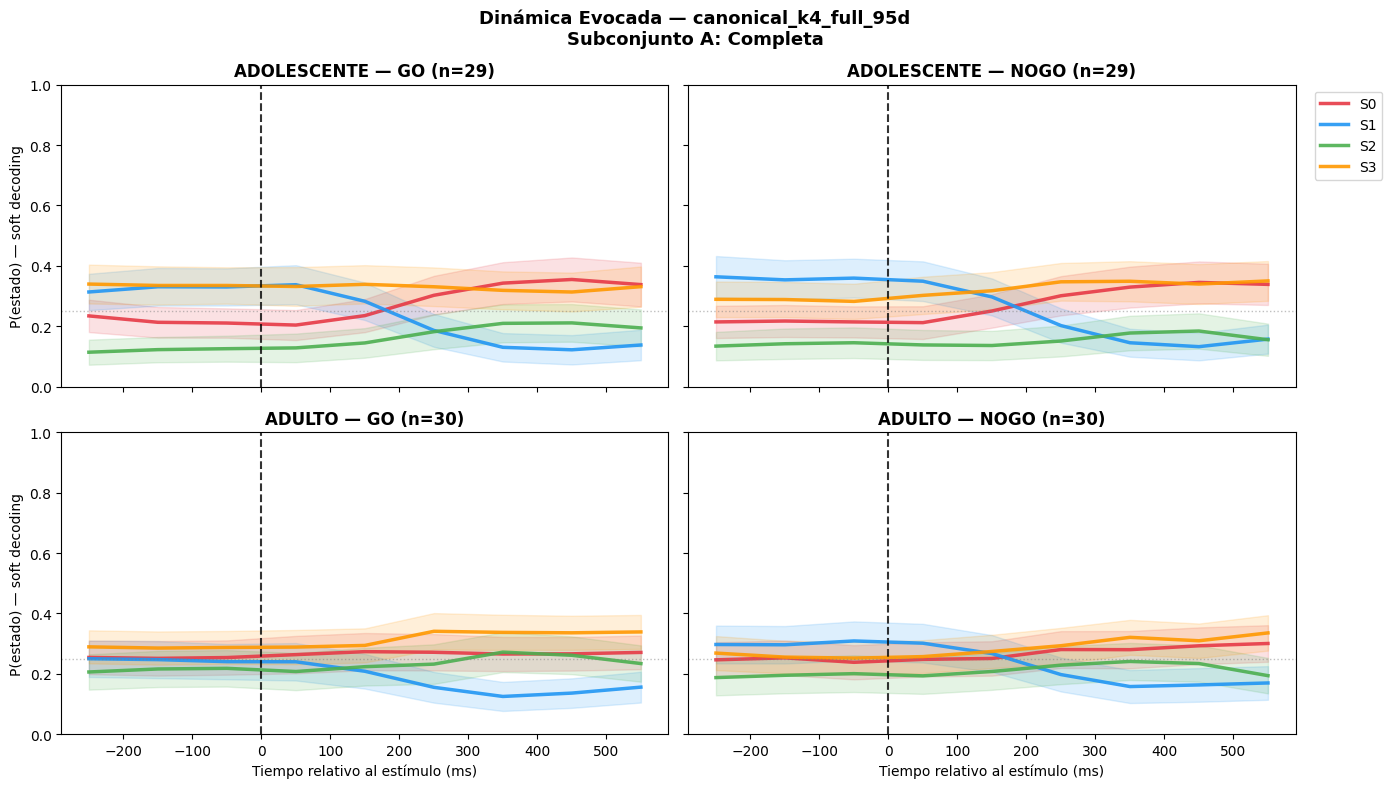

Guardado: plots/evoked_B.png


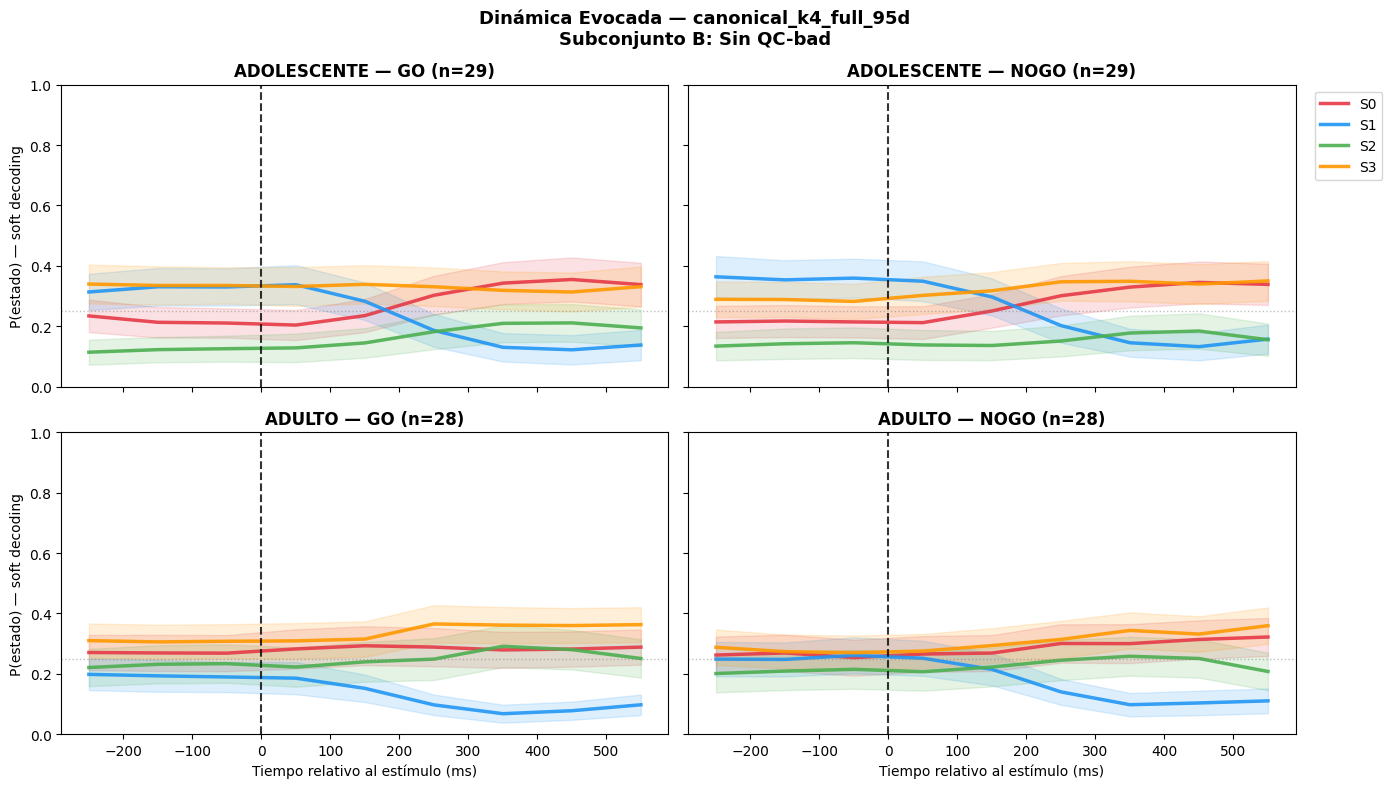

Guardado: plots/evoked_C.png


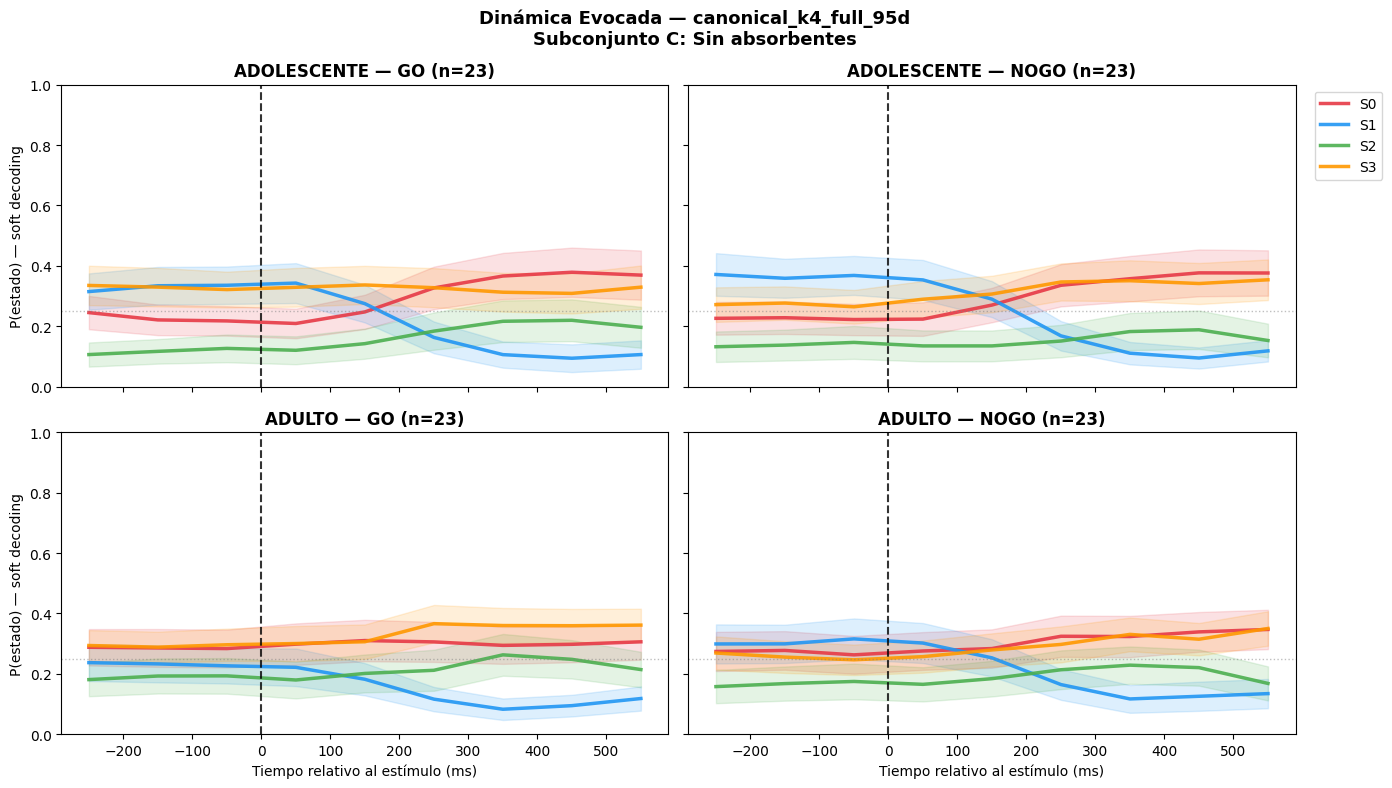

Guardado: plots/evoked_gonogo_A.png


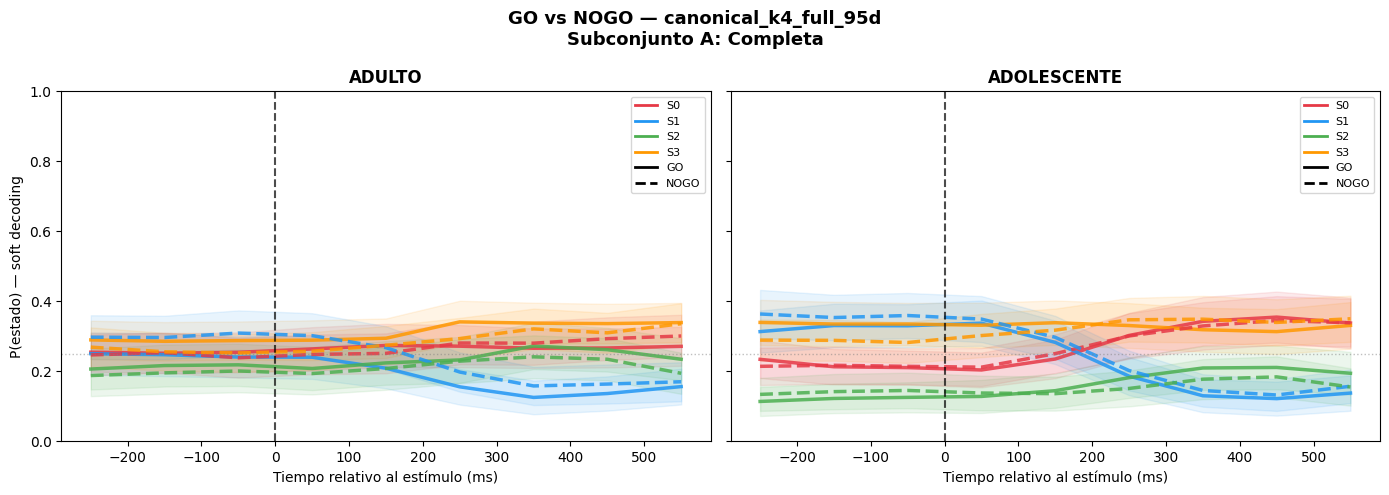

Guardado: plots/evoked_gonogo_B.png


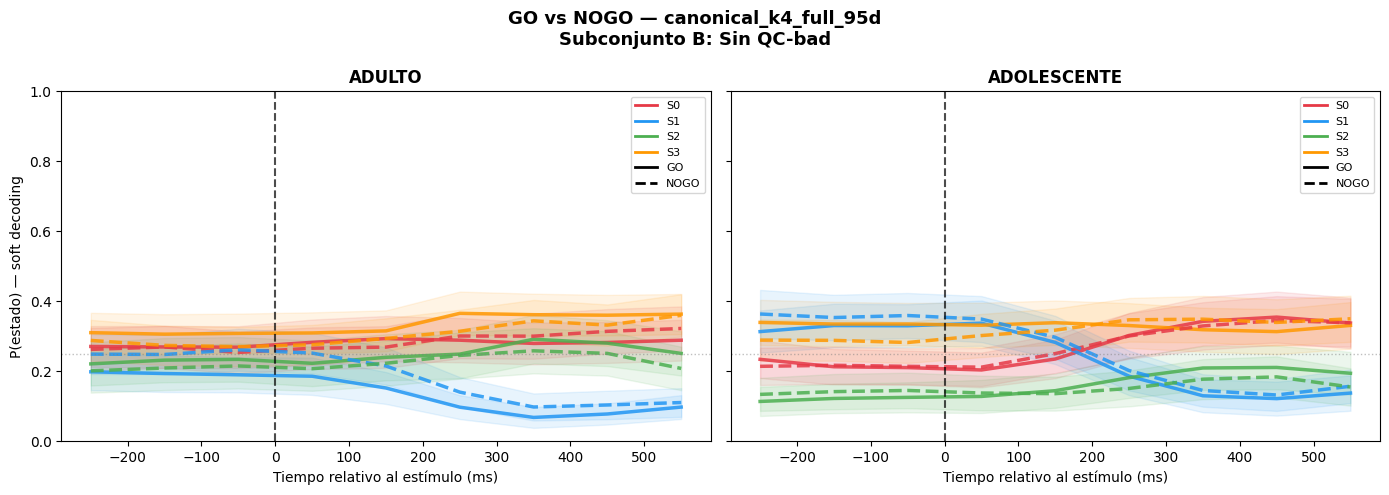

Guardado: plots/evoked_gonogo_C.png


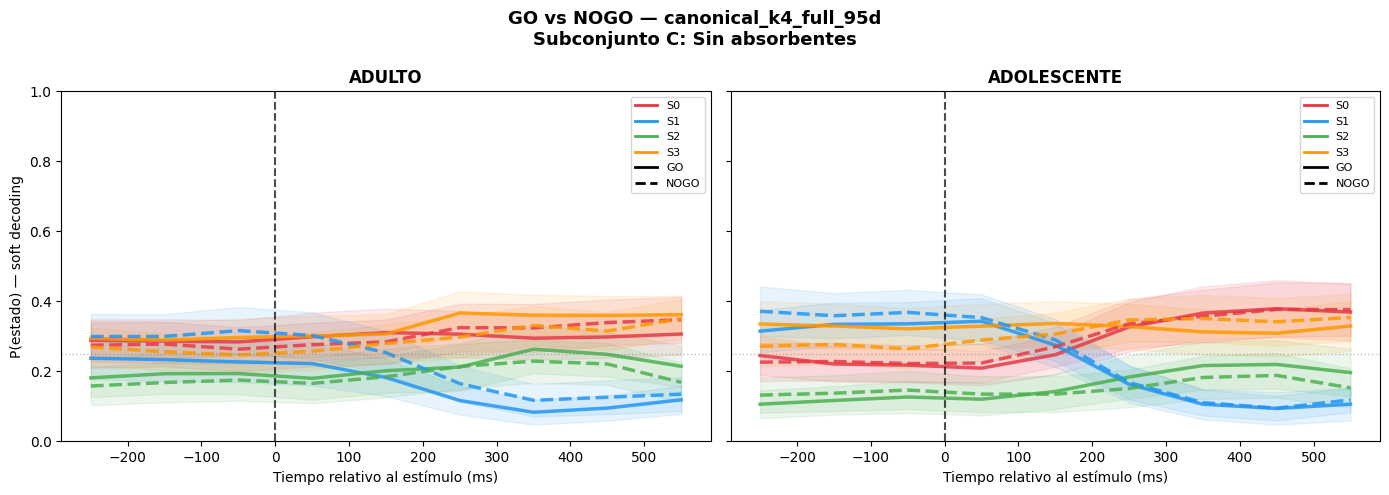


=== ROBUSTEZ: Comparativa A vs B por estado ===
  ADULTO GO: Δ_max(A→B) = 0.0585 ⚠️ revisar
  ADULTO NOGO: Δ_max(A→B) = 0.0601 ⚠️ revisar
  ADOLESCENTE GO: Δ_max(A→B) = 0.0000 ✅ robusto
  ADOLESCENTE NOGO: Δ_max(A→B) = 0.0000 ✅ robusto


In [24]:
# ============================================================
# DINÁMICA EVOCADA — alineada trial a trial
# ============================================================
import matplotlib.pyplot as plt
import unicodedata
from collections import Counter

import os

def save_fig(fig_name, extension='png', dpi=300):
    # Ensure a directory for your plots exists
    os.makedirs('plots', exist_ok=True)
    
    # Construct the full path and save
    file_path = f'plots/{fig_name}.{extension}'
    plt.savefig(file_path, bbox_inches='tight', dpi=dpi)
    print(f'Guardado: {file_path}')

# ── Parámetros temporales ────────────────────────────────────
EPOCH_TMIN_S  = -0.500   # tmin de las épocas en segundos
EDGE_TRIM     = 1        # ventanas recortadas al inicio
WINDOW_MS_    = 300.0
STEP_MS_      = 100.0
N_WIN_TRIAL   = 9        # ventanas por trial (del lengths.npy)

# Centro de cada ventana relativo al estímulo (en ms)
t_centers_ms = np.array([
    (EPOCH_TMIN_S * 1000                    # inicio de época
     + EDGE_TRIM * STEP_MS_                 # edge trim
     + i * STEP_MS_                         # avance por ventana
     + WINDOW_MS_ / 2)                      # centro de ventana
    for i in range(N_WIN_TRIAL)
])
print("Tiempos de ventana relativos al estímulo (ms):")
print(np.round(t_centers_ms).astype(int))

# ── Subconjuntos ─────────────────────────────────────────────
def norm_id(s):
    return unicodedata.normalize('NFD', s).encode(
        'ascii','ignore').decode('ascii').upper()

EXCLUIR_B = ['GGMSIN', 'CJGSIN']
EXCLUIR_C = EXCLUIR_B + [
    'AGOSIN','JMTS','MRAGSIN','SEOOSIN','MCVSIN',
    'DMGSIN','RAMPSIN','FVGSIN','BMPSC','IABWSC','CGMSIN'
]

def make_mask(subject_meta, excluir):
    return np.array([
        not any(norm_id(m['subject_id']).startswith(norm_id(e))
                for e in excluir)
        for m in subject_meta
    ])

mask_A = np.ones(len(subject_meta), dtype=bool)
mask_B = make_mask(subject_meta, EXCLUIR_B)
mask_C = make_mask(subject_meta, EXCLUIR_C)

subsets = {
    'A': (mask_A, 'Completa'),
    'B': (mask_B, 'Sin QC-bad'),
    'C': (mask_C, 'Sin absorbentes'),
}

# ── Función de dinámica evocada ──────────────────────────────
def compute_evoked_trials(subject_meta, posterior,
                          n_states, n_win_trial,
                          mask, group, cond):
    """
    Para cada sujeto del grupo/condición:
      - Extrae sus ventanas del posterior
      - Reshapea en (n_trials, n_win_trial, n_states)
      - Promedia sobre trials → (n_win_trial, n_states)
    Devuelve stack de shape (n_subjects, n_win_trial, n_states)
    """
    trials_por_sujeto = []
    sujetos_incluidos = 0

    for i, m in enumerate(subject_meta):
        if not mask[i]:
            continue
        if m['group'] != group or m['condition'] != cond:
            continue

        p = posterior[m['start']:m['end']]  # (n_ventanas_sesion, n_states)
        n_total = len(p)

        # Verifica que es divisible por n_win_trial
        n_trials = n_total // n_win_trial
        if n_trials == 0:
            continue

        # Reshape: (n_trials, n_win_trial, n_states)
        p_trials = p[:n_trials * n_win_trial].reshape(
            n_trials, n_win_trial, n_states
        )
        # Media sobre trials del sujeto
        p_mean = p_trials.mean(axis=0)  # (n_win_trial, n_states)
        trials_por_sujeto.append(p_mean)
        sujetos_incluidos += 1

    if not trials_por_sujeto:
        return None, None, None, 0

    stack = np.array(trials_por_sujeto)  # (n_sujetos, n_win, n_states)
    mean_p = stack.mean(axis=0)          # (n_win, n_states)
    sem_p  = stack.std(axis=0) / np.sqrt(len(stack))

    return t_centers_ms, mean_p, sem_p, sujetos_incluidos

# ── Plot 1: 4 paneles por subconjunto ────────────────────────
combos = [
    ('ADOLESCENTE','GO'),
    ('ADOLESCENTE','NOGO'),
    ('ADULTO','GO'),
    ('ADULTO','NOGO'),
]

for subset_key, (mask, subset_label) in subsets.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 8),
                              sharex=True, sharey=True)
    positions = [(0,0),(0,1),(1,0),(1,1)]

    for (row, col), (group, cond) in zip(positions, combos):
        ax = axes[row, col]
        t_ms, mean_p, sem_p, n_sub = compute_evoked_trials(
            subject_meta, posterior, N_STATES,
            N_WIN_TRIAL, mask, group, cond
        )

        if t_ms is None:
            ax.text(0.5, 0.5, 'Sin datos', ha='center',
                    va='center', transform=ax.transAxes)
            continue

        for s in range(N_STATES):
            ax.plot(t_ms, mean_p[:, s],
                    color=STATE_COLORS[s], lw=2.5,
                    label=f'S{s}', alpha=0.9)
            ax.fill_between(
                t_ms,
                mean_p[:, s] - sem_p[:, s],
                mean_p[:, s] + sem_p[:, s],
                color=STATE_COLORS[s], alpha=0.15
            )

        ax.axvline(0, color='black', lw=1.5,
                   linestyle='--', alpha=0.8)
        ax.axhline(1/N_STATES, color='gray',
                   lw=1, linestyle=':', alpha=0.5)
        ax.set_title(f'{group} — {cond} (n={n_sub})',
                     fontweight='bold')
        ax.set_ylim(0, 1)
        if row == 1:
            ax.set_xlabel('Tiempo relativo al estímulo (ms)')
        if col == 0:
            ax.set_ylabel('P(estado) — soft decoding')

    axes[0,1].legend(bbox_to_anchor=(1.02,1), loc='upper left')
    plt.suptitle(
        f'Dinámica Evocada — {EXP_LABEL}\nSubconjunto {subset_key}: {subset_label}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    save_fig(f'evoked_{subset_key}')
    plt.show()

# ── Plot 2: GO vs NOGO directo por grupo ────────────────────
from matplotlib.lines import Line2D

for subset_key, (mask, subset_label) in subsets.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                              sharex=True, sharey=True)

    for col, group in enumerate(['ADULTO', 'ADOLESCENTE']):
        ax = axes[col]

        for cond, ls in [('GO', '-'), ('NOGO', '--')]:
            t_ms, mean_p, sem_p, n_sub = compute_evoked_trials(
                subject_meta, posterior, N_STATES,
                N_WIN_TRIAL, mask, group, cond
            )
            if t_ms is None:
                continue

            for s in range(N_STATES):
                ax.plot(t_ms, mean_p[:, s],
                        color=STATE_COLORS[s],
                        lw=2.5, linestyle=ls, alpha=0.85)
                ax.fill_between(
                    t_ms,
                    mean_p[:, s] - sem_p[:, s],
                    mean_p[:, s] + sem_p[:, s],
                    color=STATE_COLORS[s], alpha=0.10
                )

        ax.axvline(0, color='black', lw=1.5,
                   linestyle='--', alpha=0.7)
        ax.axhline(1/N_STATES, color='gray',
                   lw=1, linestyle=':', alpha=0.5)
        ax.set_title(f'{group}', fontweight='bold')
        ax.set_ylim(0, 1)
        ax.set_xlabel('Tiempo relativo al estímulo (ms)')
        if col == 0:
            ax.set_ylabel('P(estado) — soft decoding')

        handles = [
            Line2D([0],[0], color=STATE_COLORS[s],
                   lw=2, label=f'S{s}')
            for s in range(N_STATES)
        ] + [
            Line2D([0],[0], color='black',
                   lw=2, ls='-',  label='GO'),
            Line2D([0],[0], color='black',
                   lw=2, ls='--', label='NOGO'),
        ]
        ax.legend(handles=handles,
                  loc='upper right', fontsize=8)

    plt.suptitle(
        f'GO vs NOGO — {EXP_LABEL}\nSubconjunto {subset_key}: {subset_label}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    save_fig(f'evoked_gonogo_{subset_key}')
    plt.show()

# ── Verificación de consistencia entre subconjuntos ─────────
print("\n=== ROBUSTEZ: Comparativa A vs B por estado ===")
for group in ['ADULTO', 'ADOLESCENTE']:
    for cond in ['GO', 'NOGO']:
        _, mp_A, _, n_A = compute_evoked_trials(
            subject_meta, posterior, N_STATES,
            N_WIN_TRIAL, mask_A, group, cond)
        _, mp_B, _, n_B = compute_evoked_trials(
            subject_meta, posterior, N_STATES,
            N_WIN_TRIAL, mask_B, group, cond)
        if mp_A is None or mp_B is None:
            continue
        delta_max = np.abs(mp_A - mp_B).max()
        print(f"  {group} {cond}: Δ_max(A→B) = {delta_max:.4f} "
              f"{'✅ robusto' if delta_max < 0.02 else '⚠️ revisar'}")

In [25]:
# Dónde exactamente difieren adultos A vs B
for cond in ['GO', 'NOGO']:
    _, mp_A, _, _ = compute_evoked_trials(
        subject_meta, posterior, N_STATES,
        N_WIN_TRIAL, mask_A, 'ADULTO', cond)
    _, mp_B, _, _ = compute_evoked_trials(
        subject_meta, posterior, N_STATES,
        N_WIN_TRIAL, mask_B, 'ADULTO', cond)
    
    diff = mp_A - mp_B  # (n_win, n_states)
    print(f"\nADULTO {cond} — Diferencia A-B por estado y ventana:")
    for s in range(N_STATES):
        print(f"  S{s}: {np.round(diff[:, s], 3)}")
    print(f"  Estado con mayor diferencia: S{np.abs(diff).mean(axis=0).argmax()}")


ADULTO GO — Diferencia A-B por estado y ventana:
  S0: [-0.016 -0.018 -0.015 -0.019 -0.02  -0.017 -0.014 -0.016 -0.018]
  S1: [0.052 0.054 0.051 0.054 0.057 0.058 0.057 0.058 0.058]
  S2: [-0.015 -0.015 -0.016 -0.015 -0.016 -0.017 -0.019 -0.019 -0.017]
  S3: [-0.021 -0.02  -0.021 -0.021 -0.021 -0.024 -0.024 -0.024 -0.024]
  Estado con mayor diferencia: S1

ADULTO NOGO — Diferencia A-B por estado y ventana:
  S0: [-0.016 -0.016 -0.015 -0.018 -0.018 -0.02  -0.02  -0.021 -0.021]
  S1: [0.048 0.048 0.048 0.05  0.052 0.057 0.06  0.06  0.059]
  S2: [-0.013 -0.014 -0.014 -0.014 -0.015 -0.016 -0.017 -0.017 -0.014]
  S3: [-0.019 -0.018 -0.018 -0.018 -0.02  -0.021 -0.023 -0.022 -0.024]
  Estado con mayor diferencia: S1


---
## 10 — Caracterización de Sujetos Absorbentes

> Análisis detallado de las **18 sesiones absorbentes** (FO > 0.95 en un estado).  
> Requiere que el Bloque 7 y el Bloque 10 hayan sido ejecutados (`absorbing`, `absorbing_idx`, `fo_matrix`).

| Análisis | Qué responde |
|---|---|
| **1 — Perfil de features** | ¿Se diferencian fenotípicamente de los sujetos normales? |
| **2 — Distancia al centroide** | ¿Están más cerca o más lejos del centroide gaussiano? |
| **3 — Dinámica temporal** | ¿La absorción ocurre desde el inicio o se instala progresivamente? |
| **4 — Transiciones** | ¿Tienen menos transiciones que el resto? |
| **5 — Topomapas** | ¿El patrón EEG del absorbente difiere del grupo? (top 3 FO) |

In [ ]:
# ============================================================
# BLOQUE 12 — CARACTERIZACIÓN DE SUJETOS ABSORBENTES
# ============================================================

if not absorbing_idx:
    print("✅ No hay sujetos absorbentes — sección omitida.")
else:
    n_abs         = len(absorbing_idx)
    n_feat_per_ch = (n_actual // N_CHANNELS) if X_scaled is not None else None
    abs_set       = set(absorbing_idx)
    non_abs_idx   = [i for i in range(len(subject_meta)) if i not in abs_set]

    # Estado absorbente de cada sesión (argmax de FO)
    abs_state_map = {i: int(np.argmax(fo_matrix[i])) for i in absorbing_idx}

    # ================================================================
    # 1 — PERFIL DE FEATURES
    # ================================================================
    if X_scaled is not None:
        display(Markdown("### 1 — Perfil de Features: Absorbentes vs Resto"))

        feat_labels   = FEATURE_TYPES[:n_feat_per_ch]
        heatmap_rows  = []
        heatmap_index = []

        for i in absorbing_idx:
            m   = subject_meta[i]
            mu  = X_scaled[m['start']:m['end']].mean(axis=0)
            st  = abs_state_map[i]
            row = [mu[[c * n_feat_per_ch + fi for c in range(N_CHANNELS)]].mean()
                   for fi in range(n_feat_per_ch)]
            heatmap_rows.append(row)
            heatmap_index.append(f"{m['subject_id']} ({m['condition']}) →S{st}")

        mu_rest  = np.vstack([X_scaled[subject_meta[j]['start']:subject_meta[j]['end']]
                               for j in non_abs_idx]).mean(axis=0)
        row_rest = [mu_rest[[c * n_feat_per_ch + fi for c in range(N_CHANNELS)]].mean()
                    for fi in range(n_feat_per_ch)]
        heatmap_rows.append(row_rest)
        heatmap_index.append('— Resto (no absorbentes)')

        df_hmap = pd.DataFrame(heatmap_rows, index=heatmap_index, columns=feat_labels)

        fig, ax = plt.subplots(figsize=(7, max(4, 0.38 * len(heatmap_rows))))
        sns.heatmap(df_hmap, ax=ax, cmap='RdBu_r', center=0,
                    annot=True, fmt='.3f', linewidths=0.5, annot_kws={'size': 8})
        ax.set_title(f'Perfil de Features por Sujeto Absorbente — {EXP_LABEL}',
                     fontweight='bold')
        ax.set_xlabel('Feature (media sobre canales)')
        plt.tight_layout()
        save_fig('absorbing_01_feature_profile')
        plt.show()
    else:
        print("⚠️  X_scaled no disponible — saltando análisis 1.")

    # ================================================================
    # 2 — DISTANCIA AL CENTROIDE DEL ESTADO
    # ================================================================
    display(Markdown("### 2 — Distancia al Centroide del Estado Absorbente"))

    dist_rows = []
    for i in absorbing_idx:
        m        = subject_meta[i]
        st       = abs_state_map[i]
        centroid = model.means_[st]
        dists_i  = np.linalg.norm(X_pca[m['start']:m['end']] - centroid, axis=1)

        dists_rest_vals = np.array([
            np.linalg.norm(
                X_pca[subject_meta[j]['start']:subject_meta[j]['end']] - centroid,
                axis=1).mean()
            for j in non_abs_idx
        ])

        dist_rows.append({
            'Sujeto':           m['subject_id'],
            'Condición':        m['condition'],
            'Grupo':            m['group'],
            'Estado':           f'S{st}',
            'FO':               round(fo_matrix[i, st], 4),
            'dist_media':       round(float(dists_i.mean()), 4),
            'dist_std':         round(float(dists_i.std()),  4),
            'dist_resto_media': round(float(dists_rest_vals.mean()), 4),
            'z_score':          round(float(
                (dists_i.mean() - dists_rest_vals.mean()) /
                (dists_rest_vals.std() + 1e-9)), 3),
        })

    df_dist = pd.DataFrame(dist_rows).set_index('Sujeto')
    display(df_dist.style
        .background_gradient(subset=['dist_media'], cmap='Oranges')
        .background_gradient(subset=['z_score'],    cmap='RdBu_r', vmin=-3, vmax=3)
        .background_gradient(subset=['FO'],         cmap='Reds')
        .format({'FO': '{:.4f}', 'dist_media': '{:.4f}', 'dist_std': '{:.4f}',
                 'dist_resto_media': '{:.4f}', 'z_score': '{:+.3f}'}))

    fig, ax = plt.subplots(figsize=(6, 4))
    dist_abs_vals  = [r['dist_media']        for r in dist_rows]
    dist_rest_vals = [r['dist_resto_media']  for r in dist_rows]
    bp = ax.boxplot([dist_abs_vals, dist_rest_vals],
                    labels=['Absorbentes', 'Resto (por estado)'],
                    patch_artist=True, widths=0.45,
                    medianprops=dict(color='black', lw=2))
    bp['boxes'][0].set_facecolor('#E63946'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2196F3'); bp['boxes'][1].set_alpha(0.6)
    for j, vals in enumerate([dist_abs_vals, dist_rest_vals]):
        ax.scatter(np.random.normal(j+1, 0.06, len(vals)), vals,
                   alpha=0.65, s=22, zorder=3, color=['#E63946', '#2196F3'][j])
    ax.set_ylabel('Distancia euclidiana media (espacio PCA)')
    ax.set_title('Distancia al centroide del estado absorbente', fontweight='bold')
    plt.tight_layout()
    save_fig('absorbing_02_centroid_dist')
    plt.show()

    # ================================================================
    # 3 — DINÁMICA TEMPORAL DE ABSORCIÓN
    # ================================================================
    display(Markdown("### 3 — Dinámica Temporal: ¿Cuándo se instala la absorción?"))

    states_present = sorted(set(abs_state_map[i] for i in absorbing_idx))
    onset_rows     = []

    fig, ax = plt.subplots(figsize=(14, 5))

    for i in absorbing_idx:
        m     = subject_meta[i]
        st    = abs_state_map[i]
        p_sub = posterior[m['start']:m['end'], st]
        t_s   = np.arange(len(p_sub)) * STEP_MS / 1000
        ax.plot(t_s, p_sub, color=STATE_COLORS[st], alpha=0.45, lw=1.0)

        above     = np.where(p_sub > 0.95)[0]
        onset_pct = round(100 * above[0] / len(p_sub), 1) if len(above) > 0 else np.nan
        pct_above = round(100 * len(above) / len(p_sub), 1)
        onset_rows.append({
            'Sujeto':                m['subject_id'],
            'Condición':             m['condition'],
            'Estado':                f'S{st}',
            'Primer cruce 0.95 (%)': onset_pct,
            '% ventanas >0.95':      pct_above,
        })

    ax.axhline(0.95, color='red', lw=1.5, linestyle='--', label='Umbral 0.95')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Tiempo dentro de la sesión (s)')
    ax.set_ylabel('P(estado absorbente | datos)')
    ax.set_title(f'¿Cuándo se instala la absorción? — {EXP_LABEL}\n'
                 '(cada línea = 1 sesión, color = estado absorbente)',
                 fontweight='bold')
    for st in states_present:
        n_st = sum(1 for i in absorbing_idx if abs_state_map[i] == st)
        ax.plot([], [], color=STATE_COLORS[st], lw=2, label=f'S{st} (n={n_st})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    save_fig('absorbing_03_temporal_dynamics')
    plt.show()

    df_onset = pd.DataFrame(onset_rows).set_index('Sujeto')
    display(df_onset.style
        .background_gradient(subset=['% ventanas >0.95'], cmap='Reds')
        .format({'Primer cruce 0.95 (%)': '{:.1f}',
                 '% ventanas >0.95':      '{:.1f}%'}))

    # ================================================================
    # 4 — CONTEO DE TRANSICIONES
    # ================================================================
    display(Markdown("### 4 — Número de Transiciones: Absorbentes vs No Absorbentes"))

    def count_transitions(v):
        return int(np.sum(v[1:] != v[:-1]))

    n_trans_all = np.array([
        count_transitions(viterbi[m['start']:m['end']]) for m in subject_meta
    ])

    trans_abs  = n_trans_all[absorbing_idx]
    trans_rest = n_trans_all[[i for i in range(len(subject_meta)) if i not in abs_set]]

    stat_mw, pval_mw = stats.mannwhitneyu(trans_abs, trans_rest, alternative='two-sided')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    bp2 = axes[0].boxplot([trans_abs, trans_rest],
                           labels=['Absorbentes', 'No absorbentes'],
                           patch_artist=True, widths=0.45,
                           medianprops=dict(color='black', lw=2))
    bp2['boxes'][0].set_facecolor('#E63946'); bp2['boxes'][0].set_alpha(0.6)
    bp2['boxes'][1].set_facecolor('#2196F3'); bp2['boxes'][1].set_alpha(0.6)
    for j, vals in enumerate([trans_abs, trans_rest]):
        axes[0].scatter(np.random.normal(j+1, 0.06, len(vals)), vals,
                        alpha=0.65, s=22, zorder=3, color=['#E63946', '#2196F3'][j])
    axes[0].set_ylabel('N° transiciones')
    axes[0].set_title('Transiciones de estado por sesión', fontweight='bold')
    axes[0].text(0.98, 0.98, f'Mann-Whitney\np={pval_mw:.4f}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    axes[1].hist(trans_rest, bins=20, alpha=0.6, color='#2196F3', density=True,
                 label=f'No absorbentes (n={len(trans_rest)})')
    axes[1].hist(trans_abs,  bins=max(5, n_abs // 2), alpha=0.75, color='#E63946',
                 density=True, label=f'Absorbentes (n={n_abs})')
    axes[1].set_xlabel('N° transiciones')
    axes[1].set_ylabel('Densidad')
    axes[1].set_title('Distribución de transiciones', fontweight='bold')
    axes[1].legend()

    plt.suptitle(f'Transiciones de Estado — {EXP_LABEL}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('absorbing_04_transitions')
    plt.show()

    df_trans = (pd.DataFrame([{
        'Sujeto':         subject_meta[i]['subject_id'],
        'Condición':      subject_meta[i]['condition'],
        'Grupo':          subject_meta[i]['group'],
        'Estado':         f'S{abs_state_map[i]}',
        'FO':             round(fo_matrix[i, abs_state_map[i]], 4),
        'N transiciones': int(n_trans_all[i]),
    } for i in absorbing_idx])
    .set_index('Sujeto')
    .sort_values('N transiciones'))

    display(df_trans.style
        .background_gradient(subset=['N transiciones'], cmap='RdYlGn')
        .background_gradient(subset=['FO'],             cmap='Reds')
        .format({'FO': '{:.4f}'}))

    # ================================================================
    # 5 — TOPOMAPAS INDIVIDUALES vs GRUPO (top 3 FO más extrema)
    # ================================================================
    try:
        import mne
        MNE_OK2 = True
    except ImportError:
        MNE_OK2 = False

    if not MNE_OK2:
        print("⚠️  MNE no disponible — saltando topomapas individuales (análisis 5).")
    elif X_scaled is None:
        print("⚠️  X_scaled no disponible — saltando topomapas individuales (análisis 5).")
    else:
        display(Markdown("### 5 — Topomapas: Sujeto Absorbente vs Grupo (Top 3 FO)"))

        top3      = sorted(absorbing_idx,
                           key=lambda i: -fo_matrix[i, abs_state_map[i]])[:3]
        global_mu = X_scaled.mean(axis=0)

        info_tp = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=250, ch_types='eeg')
        info_tp.set_montage('standard_1020')

        for rank, i in enumerate(top3):
            m       = subject_meta[i]
            st      = abs_state_map[i]
            fo_val  = fo_matrix[i, st]
            subj_mu = X_scaled[m['start']:m['end']].mean(axis=0)

            fig, axes_tp = plt.subplots(n_feat_per_ch, 2,
                                        figsize=(6.5, 2.8 * n_feat_per_ch))
            if n_feat_per_ch == 1:
                axes_tp = axes_tp.reshape(1, -1)

            for fi, feat_type in enumerate(FEATURE_TYPES[:n_feat_per_ch]):
                feat_idx = [c * n_feat_per_ch + fi for c in range(N_CHANNELS)]
                vmin_fi  = min(subj_mu[feat_idx].min(), global_mu[feat_idx].min())
                vmax_fi  = max(subj_mu[feat_idx].max(), global_mu[feat_idx].max())

                mne.viz.plot_topomap(
                    subj_mu[feat_idx], info_tp, axes=axes_tp[fi, 0],
                    show=False, vlim=(vmin_fi, vmax_fi), cmap='RdBu_r', contours=4)
                mne.viz.plot_topomap(
                    global_mu[feat_idx], info_tp, axes=axes_tp[fi, 1],
                    show=False, vlim=(vmin_fi, vmax_fi), cmap='RdBu_r', contours=4)

                axes_tp[fi, 0].set_ylabel(feat_type, fontsize=9)
                if fi == 0:
                    axes_tp[fi, 0].set_title(
                        f'{m["subject_id"]} ({m["condition"]})\n'
                        f'FO={fo_val:.4f} → S{st}',
                        fontweight='bold', color='red', fontsize=9)
                    axes_tp[fi, 1].set_title('Grupo (todos)\nmedia',
                                              fontweight='bold', fontsize=9)

            plt.suptitle(f'Absorbente #{rank+1} vs Grupo — {EXP_LABEL}',
                         fontsize=11, fontweight='bold')
            plt.tight_layout()
            save_fig(f'absorbing_05_topomap_top{rank+1}')
            plt.show()

    # ================================================================
    # TABLA RESUMEN FINAL
    # ================================================================
    display(Markdown("### Tabla Resumen — Todos los Sujetos Absorbentes"))

    summary_rows = []
    for k, i in enumerate(absorbing_idx):
        m   = subject_meta[i]
        st  = abs_state_map[i]
        p_s = posterior[m['start']:m['end'], st]
        summary_rows.append({
            'Sujeto':    m['subject_id'],
            'Condición': m['condition'],
            'Grupo':     m['group'],
            'Estado':    f'S{st}',
            'FO':        round(fo_matrix[i, st], 4),
            'z_dist':    dist_rows[k]['z_score'],
            '% v>0.95':  round(100 * float(np.mean(p_s > 0.95)), 1),
            'N trans':   int(n_trans_all[i]),
        })

    df_summary = (pd.DataFrame(summary_rows)
                  .set_index('Sujeto')
                  .sort_values('FO', ascending=False))

    display(df_summary.style
        .background_gradient(subset=['FO'],       cmap='Reds')
        .background_gradient(subset=['z_dist'],   cmap='RdBu_r', vmin=-3, vmax=3)
        .background_gradient(subset=['% v>0.95'], cmap='Reds')
        .background_gradient(subset=['N trans'],  cmap='RdYlGn')
        .format({'FO': '{:.4f}', 'z_dist': '{:+.3f}',
                 '% v>0.95': '{:.1f}%', 'N trans': '{:.0f}'}))

    print(f"\n{'='*60}")
    print(f"RESUMEN DE ABSORCIÓN — {EXP_LABEL}")
    print(f"{'='*60}")
    print(f"  Absorbentes: {n_abs}/{len(subject_meta)} "
          f"({100*n_abs/len(subject_meta):.1f}%)")
    for st in states_present:
        n_st  = sum(1 for i in absorbing_idx if abs_state_map[i] == st)
        fo_st = [fo_matrix[i, st] for i in absorbing_idx if abs_state_map[i] == st]
        print(f"  S{st}: {n_st} sesiones | FO μ={np.mean(fo_st):.4f} "
              f"| FO max={np.max(fo_st):.4f}")
    print(f"\n  Transiciones: absorbentes μ={np.mean(trans_abs):.0f} | "
          f"resto μ={np.mean(trans_rest):.0f} | Mann-Whitney p={pval_mw:.4f}")

---
## 11 — Análisis por Subconjuntos de Absorbentes

Evalúa el impacto de los sujetos absorbentes en los resultados del modelo K=3.

| Subconjunto | Descripción |
|---|---|
| **A** | Muestra completa (todas las sesiones) |
| **B** | Sin `GGMSIN` ni `CJGSIN` — exclusión por criterio objetivo de calidad de señal (QC) |
| **C** | Sin ningún absorbente identificado en K4 y K3 — muestra "limpia" |

Análisis: FO por condición, FO por grupo, dinámica evocada (placeholder), conclusión automática.

In [ ]:
# ============================================================
# BLOQUE 11 — ANÁLISIS POR SUBCONJUNTOS DE ABSORBENTES
# ============================================================

import unicodedata as _uc
from scipy import stats as _stats

# ─── Listas de exclusión ──────────────────────────────────────────
EXCLUIR_QC = ['GGMSIN', 'CJGSIN']

EXCLUIR_EXTREMOS = [
    'CGMSIN', 'CJGSIN', 'SEOOSIN', 'MRAGSIN'
]

def es_absorbente(fname, lista):
    def _norm(s):
        return _uc.normalize('NFD', s).encode('ascii', 'ignore').decode('ascii').upper()
    fname_norm = _norm(fname)
    return any(fname_norm.startswith(_norm(base)) for base in lista)

# ─── Máscaras sobre subject_meta ──────────────────────────────────
mask_A = np.ones(len(subject_meta), dtype=bool)

mask_B = np.array([
    not es_absorbente(m['subject_id'], EXCLUIR_QC)
    for m in subject_meta
])

_excluir_C = EXCLUIR_QC + EXCLUIR_EXTREMOS + [
    'AGOSIN', 'JMTS', 'MCVSIN', 'DMGSIN', 'RAMPSIN', 'FVGSIN',
    'BMPSC', 'IABWSC',
]
mask_C = np.array([
    not es_absorbente(m['subject_id'], _excluir_C)
    for m in subject_meta
])

subsets      = {'A': mask_A, 'B': mask_B, 'C': mask_C}
subset_descs = {
    'A': 'completo',
    'B': 'sin GGMSIN + CJGSIN (QC)',
    'C': 'sin absorbentes',
}

print(f"Subconjunto A (completo):          {mask_A.sum():3d} sesiones")
print(f"Subconjunto B (sin GGMSIN+CJGSIN): {mask_B.sum():3d} sesiones")
print(f"Subconjunto C (sin absorbentes):   {mask_C.sum():3d} sesiones")

# ─── Helper ───────────────────────────────────────────────────────
def fo_for_mask_cond(mask, cond):
    """Devuelve (medias, SEMs) de FO por estado para las sesiones filtradas."""
    idx = [i for i, m in enumerate(subject_meta)
           if mask[i] and m['condition'] == cond]
    if not idx:
        return np.full(N_STATES, np.nan), np.full(N_STATES, np.nan)
    mat = fo_matrix[np.array(idx)]
    return mat.mean(axis=0), mat.std(axis=0) / np.sqrt(len(idx))

# ====================================================================
# 1 — FO MEDIA POR ESTADO Y CONDICIÓN
# ====================================================================
fo_table = {}   # fo_table[subset_name][cond] = array(N_STATES,)

fig, axes_s1 = plt.subplots(3, 2, figsize=(11, 10))
fig.suptitle(f'FO por Condición × Subconjunto — {EXP_LABEL}',
             fontsize=13, fontweight='bold')

for row_i, (sname, mask) in enumerate(subsets.items()):
    fo_table[sname] = {}
    for col_j, cond in enumerate(['GO', 'NOGO']):
        ax = axes_s1[row_i, col_j]
        means, sems = fo_for_mask_cond(mask, cond)
        fo_table[sname][cond] = means

        n_cond = sum(1 for i, m in enumerate(subject_meta)
                     if mask[i] and m['condition'] == cond)
        x = np.arange(N_STATES)
        bars = ax.bar(x, means, yerr=sems, capsize=5,
                      color=STATE_COLORS[:N_STATES], alpha=0.85,
                      error_kw={'lw': 2})
        for bar, v, sem in zip(bars, means, sems):
            if np.isfinite(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        float(v) + float(sem) + 0.01,
                        f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
        ax.axhline(1 / N_STATES, color='gray', linestyle='--', alpha=0.5, lw=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels([f'S{s}' for s in range(N_STATES)])
        ax.set_ylim(0, min(1.05, float(np.nanmax(means)) * 1.35 + 0.08))
        ax.set_ylabel('FO media ± SEM')
        ax.set_title(
            f'FO por condición — Subconjunto {sname} '
            f'(n={n_cond} sesiones {cond})\n'
            f'[{subset_descs[sname]}]',
            fontweight='bold', fontsize=9)

plt.tight_layout()
save_fig('sub11_fo_by_condition')
plt.show()

# ====================================================================
# 2 — TABLA COMPARATIVA DE FO
# ====================================================================
rows_tbl = []
for s in range(N_STATES):
    row = {'Estado': f'S{s}'}
    for sn in ['A', 'B', 'C']:
        for cond in ['GO', 'NOGO']:
            row[f'FO_{cond}_{sn}'] = round(float(fo_table[sn][cond][s]), 4)
    rows_tbl.append(row)

col_order  = [f'FO_{c}_{sn}' for sn in ['A', 'B', 'C'] for c in ['GO', 'NOGO']]
df_fo_cmp  = pd.DataFrame(rows_tbl).set_index('Estado')[col_order]

display(Markdown("### 2 — Tabla comparativa FO por estado (A vs B vs C)"))
display(df_fo_cmp.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format('{:.4f}'))

max_delta_AB = 0.0
for s in range(N_STATES):
    fo_a_avg = (float(fo_table['A']['GO'][s]) + float(fo_table['A']['NOGO'][s])) / 2
    fo_b_avg = (float(fo_table['B']['GO'][s]) + float(fo_table['B']['NOGO'][s])) / 2
    max_delta_AB = max(max_delta_AB, abs(fo_b_avg - fo_a_avg))

print()
if max_delta_AB < 0.05:
    print("✅ Absorbentes no distorsionan FO por condición")
else:
    print("⚠️  Absorbentes afectan FO — usar subconjunto B como principal")
print(f"   (Δ máximo A→B promediando GO/NOGO = {max_delta_AB:.4f})")

# ====================================================================
# 3 — FO POR GRUPO (ADULTO / ADOLESCENTE)
# ====================================================================
_groups       = ['ADULTO', 'ADOLESCENTE']
_group_colors = {'ADULTO': '#E63946', 'ADOLESCENTE': '#2196F3'}

fig, axes_s3 = plt.subplots(3, N_STATES, figsize=(4 * N_STATES, 10))
fig.suptitle(
    f'FO por Grupo (Adulto/Adolescente) × Subconjunto — {EXP_LABEL}',
    fontsize=13, fontweight='bold')

for row_i, (sname, mask) in enumerate(subsets.items()):
    for s in range(N_STATES):
        ax = axes_s3[row_i, s]
        data_g = {}
        for g in _groups:
            idx_g = [i for i, m in enumerate(subject_meta)
                     if mask[i] and m['group'] == g]
            data_g[g] = fo_matrix[np.array(idx_g), s] if idx_g else np.array([])

        bp = ax.boxplot([data_g[g] for g in _groups],
                        labels=_groups, patch_artist=True,
                        medianprops=dict(color='black', lw=2), widths=0.5)
        for patch, g in zip(bp['boxes'], _groups):
            patch.set_facecolor(_group_colors[g])
            patch.set_alpha(0.7)
        for j, g in enumerate(_groups):
            y = data_g[g]
            if len(y) > 0:
                ax.scatter(np.random.normal(j + 1, 0.05, len(y)), y,
                           alpha=0.55, s=15, color=_group_colors[g], zorder=3)

        try:
            if len(data_g['ADULTO']) > 1 and len(data_g['ADOLESCENTE']) > 1:
                _, p_mw = _stats.mannwhitneyu(
                    data_g['ADULTO'], data_g['ADOLESCENTE'],
                    alternative='two-sided')
                ax.text(0.97, 0.97, f'p={p_mw:.3f}',
                        transform=ax.transAxes, ha='right', va='top', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        except Exception:
            pass

        ax.axhline(1 / N_STATES, color='gray', linestyle='--', alpha=0.4, lw=1.2)
        ax.set_title(f'Sub {sname} — S{s}', fontweight='bold',
                     color=STATE_COLORS[s], fontsize=9)
        ax.set_ylabel('FO' if s == 0 else '')
        ax.set_xticklabels(_groups, fontsize=8, rotation=15)

plt.tight_layout()
save_fig('sub11_fo_by_group')
plt.show()

# ====================================================================
# 4 — DINÁMICA EVOCADA POR SUBCONJUNTO (PLACEHOLDER)
# ====================================================================
print("\n" + "─" * 55)
print("4 — DINÁMICA EVOCADA POR SUBCONJUNTO")
print("─" * 55)
print("⏳ Dinámica evocada pendiente — implementar en próxima sesión")
print("   Requiere: tiempos de onset de estímulo alineados por trial")
print("   Estructura esperada:")
print("     Para cada subconjunto × condición:")
print("       P(estado=s | t) = promedio sobre trials y sujetos filtrados")
print("     Plot: curva temporal por estado, GO vs NOGO superpuestos")

# ====================================================================
# 5 — CONCLUSIÓN AUTOMÁTICA
# ====================================================================
print("\n" + "=" * 55)
print("=== CONCLUSIÓN SUBCONJUNTOS ===")
print("=" * 55)
for s in range(N_STATES):
    fo_a = (float(fo_table['A']['GO'][s]) + float(fo_table['A']['NOGO'][s])) / 2
    fo_b = (float(fo_table['B']['GO'][s]) + float(fo_table['B']['NOGO'][s])) / 2
    delta = abs(fo_b - fo_a)
    if delta < 0.02:
        qualifier = f"robusto (Δ={delta:.3f})"
    elif delta < 0.05:
        qualifier = f"leve efecto (Δ={delta:.3f})"
    else:
        qualifier = f"efecto significativo (Δ={delta:.3f}) ⚠️"
    print(f"  S{s}: {qualifier}")

fo_c_mean = np.nanmean([fo_table['C']['GO'], fo_table['C']['NOGO']], axis=0)
print(f"\n  Subconjunto C ({mask_C.sum()} sesiones) — FO libre de absorción:")
for s in range(N_STATES):
    print(f"    S{s}: {fo_c_mean[s]:.4f}")